# SHBT261 Mini Project 1
**Cindy Sun**\
This code runs through OnDemand.

In [1]:
# Imports
import os, time, copy, json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product

from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, top_k_accuracy_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import timm
import joblib
import shutil

warnings.filterwarnings('ignore')

print('All imports OK ✓')
print(f'PyTorch  : {torch.__version__}')
print(f'timm     : {timm.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
print(f'MPS      : {torch.backends.mps.is_available()}')

All imports OK ✓
PyTorch  : 2.10.0
timm     : 1.0.25
CUDA     : True
MPS      : False


In [2]:
# Paths
print(os.getcwd())
print(os.path.expanduser("~"))

PROJECT_DIR = Path(os.path.expanduser("~")) / "SHBT261_miniproject1"
DATA_DIR    = PROJECT_DIR / "data" / "caltech-101"
FIG_DIR     = PROJECT_DIR / "figures" / "experiments"
MODEL_DIR   = PROJECT_DIR / "models" / "experiments"
RESULTS_DIR = PROJECT_DIR / "results"

for d in [FIG_DIR, MODEL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("mps"  if torch.backends.mps.is_available()
                 else "cuda" if torch.cuda.is_available()
                 else "cpu")

print(f"Project : {PROJECT_DIR}")
print(f"Data    : {DATA_DIR}")
print(f"Device  : {DEVICE}")
print(f"Data exists: {DATA_DIR.exists()}")

/shared/home/xis553/SHBT261_miniproject1
/shared/home/xis553
Project : /shared/home/xis553/SHBT261_miniproject1
Data    : /shared/home/xis553/SHBT261_miniproject1/data/caltech-101
Device  : cuda
Data exists: True


In [3]:
# Load Data & Split 
records = []
for cls_folder in sorted(DATA_DIR.iterdir()):
    if cls_folder.is_dir() and not cls_folder.name.startswith('.'):
        for img_path in cls_folder.glob("*.jpg"):
            records.append({"image_path": str(img_path),
                            "class_name": cls_folder.name})

df = pd.DataFrame(records)
le = LabelEncoder()
df["label"] = le.fit_transform(df["class_name"])
NUM_CLASSES  = df["label"].nunique()

train_df, temp_df = train_test_split(df,      test_size=0.30, stratify=df["label"],      random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Total images : {len(df)}")
print(f"Classes      : {NUM_CLASSES}")
print(f"Train        : {len(train_df)}")
print(f"Val          : {len(val_df)}")
print(f"Test         : {len(test_df)}")

Total images : 8677
Classes      : 101
Train        : 6073
Val          : 1302
Test         : 1302


In [4]:
# HOG Feature Extraction (SVM only)
HOG_CACHE = MODEL_DIR.parent.parent / "models"

def extract_hog(img_path, size):
    img      = Image.open(img_path).convert("RGB").resize(size)
    img_gray = rgb2gray(np.array(img))
    return hog(img_gray, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), feature_vector=True)

def build_hog_arrays(dataframe, size):
    X, y = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), leave=False):
        X.append(extract_hog(row["image_path"], size))
        y.append(row["label"])
    return np.array(X, dtype=np.float32), np.array(y)

def get_hog_arrays(size):
    """Load from cache or extract HOG features for a given image size."""
    tag = f"{size[0]}x{size[1]}"
    cache_files = {
        "X_train": MODEL_DIR / f"hog_{tag}_X_train.npy",
        "y_train": MODEL_DIR / f"hog_{tag}_y_train.npy",
        "X_val":   MODEL_DIR / f"hog_{tag}_X_val.npy",
        "y_val":   MODEL_DIR / f"hog_{tag}_y_val.npy",
        "X_test":  MODEL_DIR / f"hog_{tag}_X_test.npy",
        "y_test":  MODEL_DIR / f"hog_{tag}_y_test.npy",
    }
    if all(f.exists() for f in cache_files.values()):
        print(f"  HOG {tag} cache found — loading...")
        return {k: np.load(v) for k, v in cache_files.items()}

    print(f"  Extracting HOG {tag} features (first time)...")
    X_tr, y_tr = build_hog_arrays(train_df, size)
    X_va, y_va = build_hog_arrays(val_df,   size)
    X_te, y_te = build_hog_arrays(test_df,  size)

    arrays = {"X_train": X_tr, "y_train": y_tr,
              "X_val":   X_va, "y_val":   y_va,
              "X_test":  X_te, "y_test":  y_te}
    for k, v in arrays.items():
        np.save(cache_files[k], v)
    print(f"  HOG {tag} saved ✓")
    return arrays

print("HOG extraction functions ready ✓")

HOG extraction functions ready ✓


In [5]:
# Dataset & DataLoader Helpers (for DL models)
NUM_WORKERS = 12  # since i am using ondemand server
BATCH_SIZE  = 32

class Caltech101Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(row["label"], dtype=torch.long)


def get_transforms(img_size, augment=True):
    """Returns train and val/test transforms."""
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if augment:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    return train_tf, val_tf


def get_loaders(img_size, augment=True):
    """Returns train, val, test DataLoaders."""
    train_tf, val_tf = get_transforms(img_size, augment)
    train_loader = DataLoader(Caltech101Dataset(train_df, train_tf),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(Caltech101Dataset(val_df,   val_tf),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(Caltech101Dataset(test_df,  val_tf),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader

print("Dataset helpers ready ✓")

Dataset helpers ready ✓


In [6]:
# Model Builders 
def build_model(model_name, num_classes, freeze_backbone=True):
    """Build any supported model by name."""

    if model_name == "resnet18":
        model = models.resnet18(weights="IMAGENET1K_V1")
        if freeze_backbone:
            for p in model.parameters(): p.requires_grad = False
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(model.fc.in_features, num_classes)
        )

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights="IMAGENET1K_V1")
        if freeze_backbone:
            for p in model.parameters(): p.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "vit_small":
        model = timm.create_model("vit_small_patch16_224",
                                   pretrained=True, num_classes=0)
        if freeze_backbone:
            for p in model.parameters(): p.requires_grad = False
        model.head = nn.Sequential(
            nn.LayerNorm(model.num_features),
            nn.Dropout(0.3),
            nn.Linear(model.num_features, num_classes)
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model


def get_optimizer(opt_name, params, lr, weight_decay=1e-4):
    """Return optimizer by name."""
    if opt_name == "adam":
        return optim.Adam(params, lr=lr)
    elif opt_name == "adamw":
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    elif opt_name == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9,
                         weight_decay=weight_decay, nesterov=True)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

print("Model builders ready ✓")

Model builders ready ✓


In [7]:
# Training & Evaluation Functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.long().to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.long().to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(1)
        total_loss += loss.item() * images.size(0)
        correct    += (preds == labels).sum().item()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    n = len(loader.dataset)
    return (total_loss / n, correct / n,
            np.concatenate(all_preds),
            np.concatenate(all_labels),
            np.concatenate(all_probs))


def train_dl_model(model, train_loader, val_loader, cfg, device=DEVICE):
    """Full 2-phase training: freeze → train head, unfreeze → fine-tune."""
    history   = {"train_loss": [], "train_acc": [],
                 "val_loss":   [], "val_acc":   []}
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_acc, best_weights = 0.0, copy.deepcopy(model.state_dict())

    phases = [
        {"epochs": cfg["epochs"], "lr": cfg["lr"],      "unfreeze": False},
        {"epochs": cfg["epochs"], "lr": cfg["lr"] / 10, "unfreeze": True},
    ]

    for phase_idx, phase in enumerate(phases):
        if phase["unfreeze"]:
            for p in model.parameters():
                p.requires_grad = True

        trainable = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = get_optimizer(cfg["optimizer"], trainable, phase["lr"])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=phase["epochs"]
        )

        desc = "Head only" if not phase["unfreeze"] else "Full fine-tune"
        print(f"  Phase {phase_idx+1} ({desc}) — {phase['epochs']} epochs")

        for epoch in range(phase["epochs"]):
            t0 = time.time()
            tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                              criterion, optimizer, device)
            va_loss, va_acc, _, _, _ = evaluate(model, val_loader,
                                                criterion, device)
            scheduler.step()

            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(va_loss)
            history["val_acc"].append(va_acc)

            if va_acc > best_acc:
                best_acc     = va_acc
                best_weights = copy.deepcopy(model.state_dict())

            print(f"    Epoch [{epoch+1:02d}/{phase['epochs']}] "
                  f"Train {tr_acc*100:.1f}% | Val {va_acc*100:.1f}% "
                  f"| {time.time()-t0:.1f}s")

    model.load_state_dict(best_weights)
    return model, history, best_acc


def compute_metrics(y_true, y_pred, y_prob):
    """Compute all required metrics for the report."""
    acc   = accuracy_score(y_true, y_pred)
    top5  = top_k_accuracy_score(y_true, y_prob, k=5)
    cm    = confusion_matrix(y_true, y_pred)
    pca   = cm.diagonal() / cm.sum(axis=1)  # per-class accuracy
    report = classification_report(y_true, y_pred,
                                   target_names=le.classes_,
                                   digits=3, zero_division=0,
                                   output_dict=True)
    return {
        "accuracy":        acc,
        "top5_accuracy":   top5,
        "macro_f1":        report["macro avg"]["f1-score"],
        "weighted_f1":     report["weighted avg"]["f1-score"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall":    report["macro avg"]["recall"],
        "per_class_acc":   pca.tolist(),
        "confusion_matrix": cm.tolist(),
    }

print("Training & evaluation functions ready ✓")

Training & evaluation functions ready ✓


In [8]:
# Experiment Configuration (manually input hyperparameters for gird search)

# SVM configurations (img_size only — other params fixed for practicality)
SVM_CONFIGS = [
    {"model": "svm", "img_size": 128, "C": 10,  "augment": False},
    {"model": "svm", "img_size": 128, "C": 10,  "augment": True},
    {"model": "svm", "img_size": 64,  "C": 10,  "augment": False},
    {"model": "svm", "img_size": 64,  "C": 10,  "augment": True}
]

# Deep Learning grid — all combinations will be generated
DL_MODELS     = ["resnet18", "efficientnet_b0", "vit_small"]
IMG_SIZES     = [128, 224]
EPOCHS_LIST   = [5, 10]
LR_LIST       = [1e-3, 1e-4]
OPTIMIZERS    = ["adam", "adamw", "sgd"]
AUGMENT_LIST  = [True, False]


# Generate all DL combinations
DL_CONFIGS = []
for model_name, img_size, epochs, lr, opt, aug in product(
        DL_MODELS, IMG_SIZES, EPOCHS_LIST, LR_LIST, OPTIMIZERS, AUGMENT_LIST):

    # ViT requires 224 — skip 128 for ViT
    if model_name == "vit_small" and img_size == 128:
        continue

    DL_CONFIGS.append({
        "model":     model_name,
        "img_size":  img_size,
        "epochs":    epochs,
        "lr":        lr,
        "optimizer": opt,
        "augment":   aug,
    })

print(f"SVM experiments    : {len(SVM_CONFIGS)}")
print(f"DL experiments     : {len(DL_CONFIGS)}")
print(f"Total experiments  : {len(SVM_CONFIGS) + len(DL_CONFIGS)}")
print()
print("Sample DL configs:")
for c in DL_CONFIGS[:5]:
    print(f"  {c}")

SVM experiments    : 4
DL experiments     : 120
Total experiments  : 124

Sample DL configs:
  {'model': 'resnet18', 'img_size': 128, 'epochs': 5, 'lr': 0.001, 'optimizer': 'adam', 'augment': True}
  {'model': 'resnet18', 'img_size': 128, 'epochs': 5, 'lr': 0.001, 'optimizer': 'adam', 'augment': False}
  {'model': 'resnet18', 'img_size': 128, 'epochs': 5, 'lr': 0.001, 'optimizer': 'adamw', 'augment': True}
  {'model': 'resnet18', 'img_size': 128, 'epochs': 5, 'lr': 0.001, 'optimizer': 'adamw', 'augment': False}
  {'model': 'resnet18', 'img_size': 128, 'epochs': 5, 'lr': 0.001, 'optimizer': 'sgd', 'augment': True}


In [9]:
# Results Tracker
RESULTS_FILE = RESULTS_DIR / "all_results.json"

def load_results():
    if RESULTS_FILE.exists():
        with open(RESULTS_FILE) as f:
            return json.load(f)
    return {}

def save_results(results):
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)

def make_run_key(cfg):
    """Unique string key for each config."""
    if cfg["model"] == "svm":
        return (f"svm_img{cfg['img_size']}_C{cfg['C']}"
                f"_aug{cfg['augment']}")
    return (f"{cfg['model']}_img{cfg['img_size']}"
            f"_ep{cfg['epochs']}_lr{cfg['lr']}"
            f"_{cfg['optimizer']}_aug{cfg['augment']}")

# Load any existing results (resumes from checkpoint)
all_results = load_results()
print(f"Existing completed runs: {len(all_results)}")

Existing completed runs: 124


In [10]:
# Run SVM Experiments
print("="*60)
print("RUNNING SVM EXPERIMENTS")
print("="*60)

for cfg in SVM_CONFIGS:
    run_key = make_run_key(cfg)

    if run_key in all_results:
        print(f"  SKIP (already done): {run_key}")
        continue

    print(f"\nRunning: {run_key}")
    t_start = time.time()

    # Get HOG features
    size    = (cfg["img_size"], cfg["img_size"])
    arrays  = get_hog_arrays(size)

    X_tr = arrays["X_train"].copy()
    y_tr = arrays["y_train"]
    X_te = arrays["X_test"].copy()
    y_te = arrays["y_test"]

    # Augment: add flipped versions to train
    if cfg["augment"]:
        print("  Extracting augmented HOG features...")
        X_aug, y_aug = [], []
        for _, row in tqdm(train_df.iterrows(), total=len(train_df), leave=False):
            img  = Image.open(row["image_path"]).convert("RGB").resize(size)
            flip = img.transpose(Image.FLIP_LEFT_RIGHT)
            for im in [img, flip]:
                gray = rgb2gray(np.array(im))
                X_aug.append(hog(gray, orientations=9, pixels_per_cell=(8,8),
                                 cells_per_block=(2,2), feature_vector=True))
                y_aug.append(row["label"])
        X_tr = np.array(X_aug, dtype=np.float32)
        y_tr = np.array(y_aug)

    # Scale
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # Train SVM
    print("  Training SVM (this takes a while)...")
    svm = SVC(kernel="rbf", C=cfg["C"], gamma="scale",
              probability=True, random_state=42)
    svm.fit(X_tr_sc, y_tr)

    # Evaluate
    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)
    metrics = compute_metrics(y_te, y_pred, y_prob)

    # Save model
    joblib.dump(svm,    MODEL_DIR / f"{run_key}_svm.pkl")
    joblib.dump(scaler, MODEL_DIR / f"{run_key}_scaler.pkl")

    # Record results
    elapsed = time.time() - t_start
    all_results[run_key] = {
        "config":       cfg,
        "metrics":      {k: v for k, v in metrics.items()
                         if k not in ["per_class_acc", "confusion_matrix"]},
        "per_class_acc": metrics["per_class_acc"],
        "confusion_matrix": metrics["confusion_matrix"],
        "train_time_sec": elapsed,
    }
    save_results(all_results)
    print(f"  ✓ Done — Acc: {metrics['accuracy']*100:.2f}% "
          f"| Top-5: {metrics['top5_accuracy']*100:.2f}% "
          f"| Time: {elapsed/60:.1f} min")

print("\nAll SVM experiments complete ✓")

RUNNING SVM EXPERIMENTS
  SKIP (already done): svm_img128_C10_augFalse
  SKIP (already done): svm_img128_C10_augTrue
  SKIP (already done): svm_img64_C10_augFalse
  SKIP (already done): svm_img64_C10_augTrue

All SVM experiments complete ✓


In [11]:
# Run DL Experiments
print("="*60)
print("RUNNING DEEP LEARNING EXPERIMENTS")
print(f"Total configs: {len(DL_CONFIGS)}")
print("="*60)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

for idx, cfg in enumerate(DL_CONFIGS):
    run_key = make_run_key(cfg)

    if run_key in all_results:
        print(f"[{idx+1}/{len(DL_CONFIGS)}] SKIP: {run_key}")
        continue

    print(f"\n[{idx+1}/{len(DL_CONFIGS)}] Running: {run_key}")
    t_start = time.time()

    try:
        # Build loaders
        train_loader, val_loader, test_loader = get_loaders(
            cfg["img_size"], cfg["augment"]
        )

        # Build model
        model = build_model(cfg["model"], NUM_CLASSES,
                            freeze_backbone=True).to(DEVICE)

        # Train
        model, history, best_val_acc = train_dl_model(
            model, train_loader, val_loader, cfg, DEVICE
        )

        # Evaluate on test set
        _, _, y_pred, y_true, y_prob = evaluate(
            model, test_loader, criterion, DEVICE
        )
        metrics = compute_metrics(y_true, y_pred, y_prob)

        # Save model weights
        torch.save(model.state_dict(), MODEL_DIR / f"{run_key}.pth")

        # Save training curves figure
        epochs_range = range(1, len(history["train_acc"]) + 1)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train")
        ax1.plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Val")
        ax1.axvline(x=cfg["epochs"], color="gray", linestyle="--", label="Phase 1→2")
        ax1.set_title(f"{run_key}\nAccuracy"); ax1.set_ylabel("Acc (%)"); ax1.legend()
        ax2.plot(epochs_range, history["train_loss"], label="Train")
        ax2.plot(epochs_range, history["val_loss"],   label="Val")
        ax2.axvline(x=cfg["epochs"], color="gray", linestyle="--")
        ax2.set_title("Loss"); ax2.set_ylabel("Loss"); ax2.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{run_key}_curves.png", dpi=100)
        plt.close()

        # Record results
        elapsed = time.time() - t_start
        all_results[run_key] = {
            "config":       cfg,
            "metrics":      {k: v for k, v in metrics.items()
                             if k not in ["per_class_acc", "confusion_matrix"]},
            "per_class_acc":    metrics["per_class_acc"],
            "confusion_matrix": metrics["confusion_matrix"],
            "best_val_acc":  best_val_acc,
            "history":       history,
            "train_time_sec": elapsed,
        }
        save_results(all_results)
        print(f"  ✓ Acc: {metrics['accuracy']*100:.2f}% "
              f"| Top-5: {metrics['top5_accuracy']*100:.2f}% "
              f"| F1: {metrics['macro_f1']:.3f} "
              f"| Time: {elapsed/60:.1f} min")

        # Free GPU memory
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    except Exception as e:
        print(f"  ✗ FAILED: {e}")
        all_results[run_key] = {"config": cfg, "error": str(e)}
        save_results(all_results)
        continue

print("\nAll DL experiments complete ✓")

RUNNING DEEP LEARNING EXPERIMENTS
Total configs: 120
[1/120] SKIP: resnet18_img128_ep5_lr0.001_adam_augTrue
[2/120] SKIP: resnet18_img128_ep5_lr0.001_adam_augFalse
[3/120] SKIP: resnet18_img128_ep5_lr0.001_adamw_augTrue
[4/120] SKIP: resnet18_img128_ep5_lr0.001_adamw_augFalse
[5/120] SKIP: resnet18_img128_ep5_lr0.001_sgd_augTrue
[6/120] SKIP: resnet18_img128_ep5_lr0.001_sgd_augFalse
[7/120] SKIP: resnet18_img128_ep5_lr0.0001_adam_augTrue
[8/120] SKIP: resnet18_img128_ep5_lr0.0001_adam_augFalse
[9/120] SKIP: resnet18_img128_ep5_lr0.0001_adamw_augTrue
[10/120] SKIP: resnet18_img128_ep5_lr0.0001_adamw_augFalse
[11/120] SKIP: resnet18_img128_ep5_lr0.0001_sgd_augTrue
[12/120] SKIP: resnet18_img128_ep5_lr0.0001_sgd_augFalse
[13/120] SKIP: resnet18_img128_ep10_lr0.001_adam_augTrue
[14/120] SKIP: resnet18_img128_ep10_lr0.001_adam_augFalse
[15/120] SKIP: resnet18_img128_ep10_lr0.001_adamw_augTrue
[16/120] SKIP: resnet18_img128_ep10_lr0.001_adamw_augFalse
[17/120] SKIP: resnet18_img128_ep10_lr0.

In [12]:
# Results Summary Table
all_results = load_results()  # reload in case re-run this cell

rows = []
for key, result in all_results.items():
    if "error" in result:
        continue
    cfg = result["config"]
    m   = result["metrics"]
    rows.append({
        "run_key":        key,
        "model":          cfg["model"],
        "img_size":       cfg["img_size"],
        "epochs":         cfg.get("epochs", "N/A"),
        "lr":             cfg.get("lr", "N/A"),
        "optimizer":      cfg.get("optimizer", "rbf"),
        "augment":        cfg["augment"],
        "test_acc_%":     round(m["accuracy"]        * 100, 2),
        "top5_acc_%":     round(m["top5_accuracy"]   * 100, 2),
        "macro_f1":       round(m["macro_f1"],            3),
        "weighted_f1":    round(m["weighted_f1"],         3),
        "macro_precision":round(m["macro_precision"],     3),
        "macro_recall":   round(m["macro_recall"],        3),
        "train_min":      round(result["train_time_sec"] / 60, 1),
    })

results_df = pd.DataFrame(rows).sort_values("test_acc_%", ascending=False)
results_df.to_csv(RESULTS_DIR / "summary_table.csv", index=False)

print(f"Total completed runs: {len(results_df)}")
print("\nTop 10 configurations by test accuracy:")
display(results_df.head(10))

Total completed runs: 124

Top 10 configurations by test accuracy:


,run_key,model,img_size,epochs,lr,optimizer,augment,test_acc_%,top5_acc_%,macro_f1,weighted_f1,macro_precision,macro_recall,train_min
114,vit_small_img224_ep10_lr0.001_adamw_augFalse,vit_small,224,10,0.001,adamw,False,98.23,99.69,0.974,0.982,0.978,0.971,7.5
113,vit_small_img224_ep10_lr0.001_adamw_augTrue,vit_small,224,10,0.001,adamw,True,98.00,99.77,0.969,0.980,0.972,0.970,7.6
111,vit_small_img224_ep10_lr0.001_adam_augTrue,vit_small,224,10,0.001,adam,True,98.00,99.69,0.969,0.980,0.973,0.969,7.5
112,vit_small_img224_ep10_lr0.001_adam_augFalse,vit_small,224,10,0.001,adam,False,98.00,99.92,0.969,0.980,0.972,0.968,7.5
117,vit_small_img224_ep10_lr0.0001_adam_augTrue,vit_small,224,10,0.0001,adam,True,98.00,99.92,0.968,0.980,0.974,0.966,7.5
101,vit_small_img224_ep5_lr0.001_adamw_augTrue,vit_small,224,5,0.001,adamw,True,97.77,99.85,0.966,0.977,0.973,0.965,3.8
102,vit_small_img224_ep5_lr0.001_adamw_augFalse,vit_small,224,5,0.001,adamw,False,97.70,99.77,0.966,0.977,0.969,0.965,3.8
119,vit_small_img224_ep10_lr0.0001_adamw_augTrue,vit_small,224,10,0.0001,adamw,True,97.70,99.69,0.964,0.976,0.974,0.961,7.5
120,vit_small_img224_ep10_lr0.0001_adamw_augFalse,vit_small,224,10,0.0001,adamw,False,97.62,99.46,0.962,0.976,0.969,0.960,7.4
99,vit_small_img224_ep5_lr0.001_adam_augTrue,vit_small,224,5,0.001,adam,True,97.62,99.85,0.964,0.976,0.967,0.964,3.8


In [13]:
# Save Best Model per Architecture
BEST_MODELS_DIR = MODEL_DIR.parent / "best_models"
BEST_MODELS_DIR.mkdir(parents=True, exist_ok=True)

for model_name in ["svm", "resnet18", "efficientnet_b0", "vit_small"]:
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        print(f"  {model_name}: no results yet — skipping")
        continue

    best_key = subset.iloc[0]["run_key"]   # already sorted by accuracy

    if model_name == "svm":
        # SVM saves as .pkl
        src_model  = MODEL_DIR / f"{best_key}_svm.pkl"
        src_scaler = MODEL_DIR / f"{best_key}_scaler.pkl"
        dst_model  = BEST_MODELS_DIR / f"best_svm.pkl"
        dst_scaler = BEST_MODELS_DIR / f"best_svm_scaler.pkl"
        if src_model.exists():
            shutil.copy2(src_model,  dst_model)
            shutil.copy2(src_scaler, dst_scaler)
    else:
        # DL models save as .pth
        src = MODEL_DIR / f"{best_key}.pth"
        dst = BEST_MODELS_DIR / f"best_{model_name}.pth"
        if src.exists():
            shutil.copy2(src, dst)

    acc = subset.iloc[0]["test_acc_%"]
    print(f"  ✓ {model_name}: {best_key}")
    print(f"      Accuracy: {acc}% → saved to best_models/")

# Save a README so I know which config each best model came from
readme_lines = ["# Best Models\n\n"]
for model_name in ["svm", "resnet18", "efficientnet_b0", "vit_small"]:
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        continue
    best = subset.iloc[0]
    readme_lines.append(f"## {model_name}\n")
    readme_lines.append(f"- run_key  : {best['run_key']}\n")
    readme_lines.append(f"- accuracy : {best['test_acc_%']}%\n")
    readme_lines.append(f"- top5_acc : {best['top5_acc_%']}%\n")
    readme_lines.append(f"- macro_f1 : {best['macro_f1']}\n")
    readme_lines.append(f"- config   : img={best['img_size']}, "
                        f"epochs={best['epochs']}, lr={best['lr']}, "
                        f"opt={best['optimizer']}, aug={best['augment']}\n\n")

with open(BEST_MODELS_DIR / "README.md", "w") as f:
    f.writelines(readme_lines)

print(f"\nBest models saved to: {BEST_MODELS_DIR}")
print("README.md written ✓")

  ✓ svm: svm_img64_C10_augFalse
      Accuracy: 67.36% → saved to best_models/
  ✓ resnet18: resnet18_img224_ep5_lr0.001_adamw_augFalse
      Accuracy: 97.0% → saved to best_models/
  ✓ efficientnet_b0: efficientnet_b0_img224_ep10_lr0.001_adam_augTrue
      Accuracy: 97.39% → saved to best_models/
  ✓ vit_small: vit_small_img224_ep10_lr0.001_adamw_augFalse
      Accuracy: 98.23% → saved to best_models/

Best models saved to: /shared/home/xis553/SHBT261_miniproject1/models/best_models
README.md written ✓


In [14]:
# Best Model Per Architecture
print("Best configuration per model:\n")
for model_name in ["svm", "resnet18", "efficientnet_b0", "vit_small"]:
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        print(f"  {model_name}: no results yet")
        continue
    best = subset.iloc[0]
    print(f"  {model_name}:")
    print(f"    Accuracy  : {best['test_acc_%']}%")
    print(f"    Top-5     : {best['top5_acc_%']}%")
    print(f"    Macro F1  : {best['macro_f1']}")
    print(f"    Config    : img={best['img_size']}, "
          f"epochs={best['epochs']}, lr={best['lr']}, "
          f"opt={best['optimizer']}, aug={best['augment']}")
    print(f"    Train time: {best['train_min']} min\n")

Best configuration per model:

  svm:
    Accuracy  : 67.36%
    Top-5     : 84.18%
    Macro F1  : 0.531
    Config    : img=64, epochs=N/A, lr=N/A, opt=rbf, aug=False
    Train time: 3.8 min

  resnet18:
    Accuracy  : 97.0%
    Top-5     : 99.77%
    Macro F1  : 0.954
    Config    : img=224, epochs=5, lr=0.001, opt=adamw, aug=False
    Train time: 1.3 min

  efficientnet_b0:
    Accuracy  : 97.39%
    Top-5     : 99.85%
    Macro F1  : 0.962
    Config    : img=224, epochs=10, lr=0.001, opt=adam, aug=True
    Train time: 4.5 min

  vit_small:
    Accuracy  : 98.23%
    Top-5     : 99.69%
    Macro F1  : 0.974
    Config    : img=224, epochs=10, lr=0.001, opt=adamw, aug=False
    Train time: 7.5 min



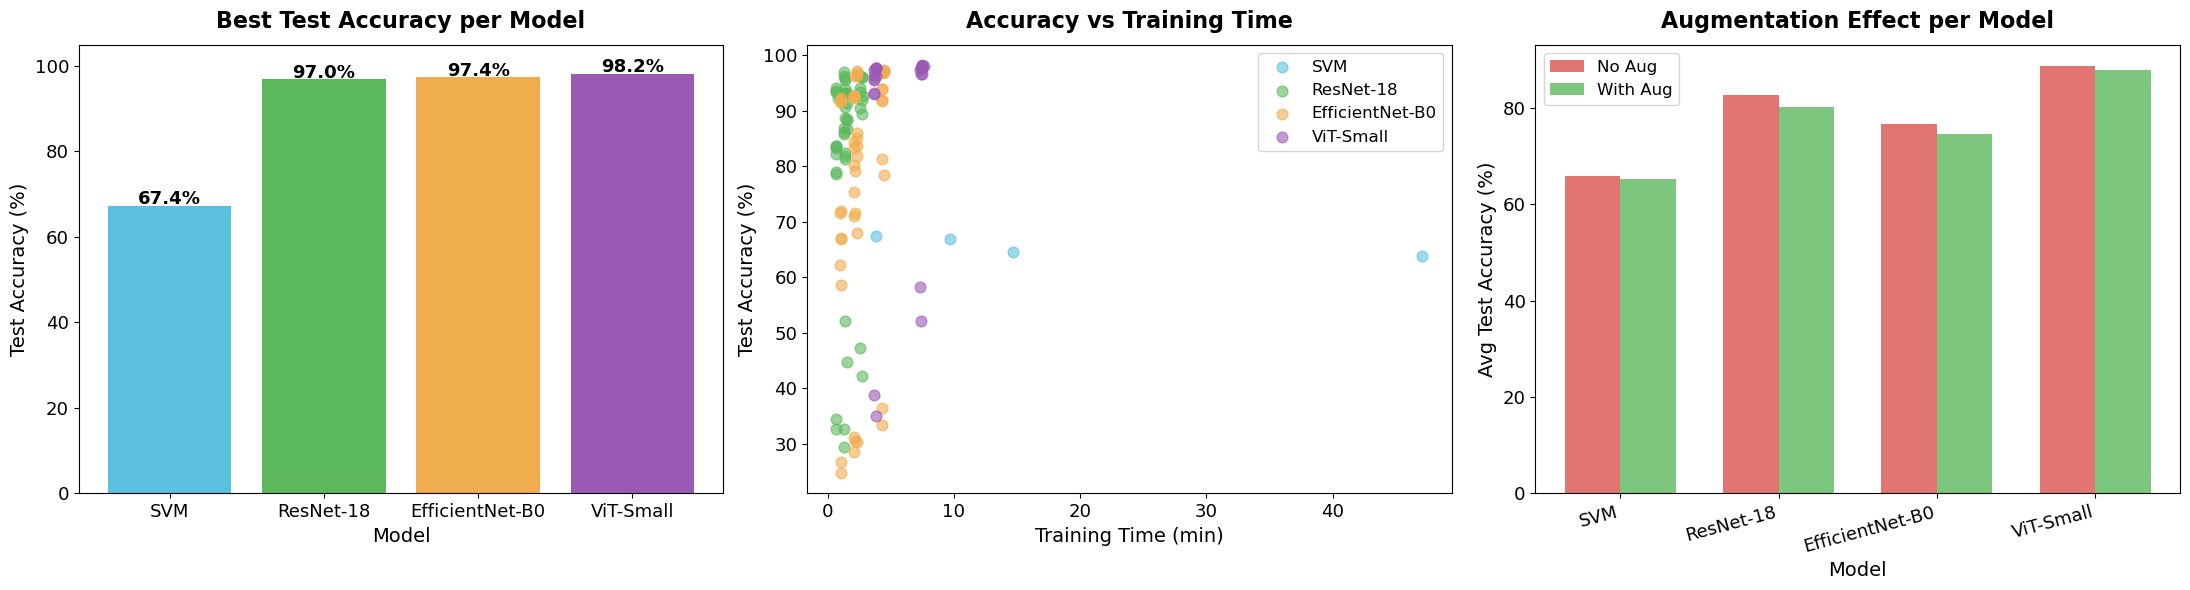

Saved: comparison_summary.png ✓


In [15]:
# Comparison Bar Chart

MODEL_ORDER = ["svm", "resnet18", "efficientnet_b0", "vit_small"]
MODEL_LABELS = {"svm": "SVM", "resnet18": "ResNet-18",
                "efficientnet_b0": "EfficientNet-B0", "vit_small": "ViT-Small"}

# Best accuracy per model — reordered
best_per_model = results_df.groupby("model")["test_acc_%"].max().reset_index()
best_per_model["model"] = pd.Categorical(best_per_model["model"], categories=MODEL_ORDER, ordered=True)
best_per_model = best_per_model.sort_values("model")

colors = {"svm": "#5bc0de", "resnet18": "#5cb85c",
          "efficientnet_b0": "#f0ad4e", "vit_small": "#9b59b6"}

TITLE_SIZE  = 16
LABEL_SIZE  = 14
TICK_SIZE   = 13
ANNOT_SIZE  = 13
LEGEND_SIZE = 12

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── Plot 1: Best accuracy per model ──────────────────────────────
ax = axes[0]
bars = ax.bar(
    [MODEL_LABELS[m] for m in best_per_model["model"]],
    best_per_model["test_acc_%"],
    color=[colors.get(m, "gray") for m in best_per_model["model"]]
)
for bar, val in zip(bars, best_per_model["test_acc_%"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f"{val:.1f}%", ha="center", fontsize=ANNOT_SIZE, fontweight="bold")
ax.set_title("Best Test Accuracy per Model", fontsize=TITLE_SIZE, fontweight="bold", pad=12)
ax.set_ylabel("Test Accuracy (%)", fontsize=LABEL_SIZE)
ax.set_xlabel("Model", fontsize=LABEL_SIZE)
ax.set_ylim(0, 105)
ax.tick_params(axis="both", labelsize=TICK_SIZE)

# ── Plot 2: Accuracy vs Training Time (scatter) ───────────────────
ax = axes[1]
for model_name in MODEL_ORDER:
    sub = results_df[results_df["model"] == model_name]
    ax.scatter(sub["train_min"], sub["test_acc_%"],
               label=MODEL_LABELS[model_name], alpha=0.6,
               color=colors.get(model_name, "gray"), s=60)
ax.set_xlabel("Training Time (min)", fontsize=LABEL_SIZE)
ax.set_ylabel("Test Accuracy (%)", fontsize=LABEL_SIZE)
ax.set_title("Accuracy vs Training Time", fontsize=TITLE_SIZE, fontweight="bold", pad=12)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.legend(fontsize=LEGEND_SIZE)

# ── Plot 3: Augmentation effect ───────────────────────────────────
ax = axes[2]
aug_effect = results_df.groupby(["model", "augment"])["test_acc_%"].mean().unstack()
aug_effect.index = pd.CategoricalIndex(aug_effect.index, categories=MODEL_ORDER, ordered=True)
aug_effect = aug_effect.sort_index()

if True in aug_effect.columns and False in aug_effect.columns:
    x = np.arange(len(aug_effect))
    w = 0.35
    ax.bar(x - w/2, aug_effect[False], width=w, label="No Aug",   color="#d9534f", alpha=0.8)
    ax.bar(x + w/2, aug_effect[True],  width=w, label="With Aug", color="#5cb85c", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in aug_effect.index],
                       rotation=15, ha="right", fontsize=TICK_SIZE)
    ax.set_ylabel("Avg Test Accuracy (%)", fontsize=LABEL_SIZE)
    ax.set_xlabel("Model", fontsize=LABEL_SIZE)
    ax.set_title("Augmentation Effect per Model", fontsize=TITLE_SIZE, fontweight="bold", pad=12)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.savefig(FIG_DIR / "comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_summary.png ✓")

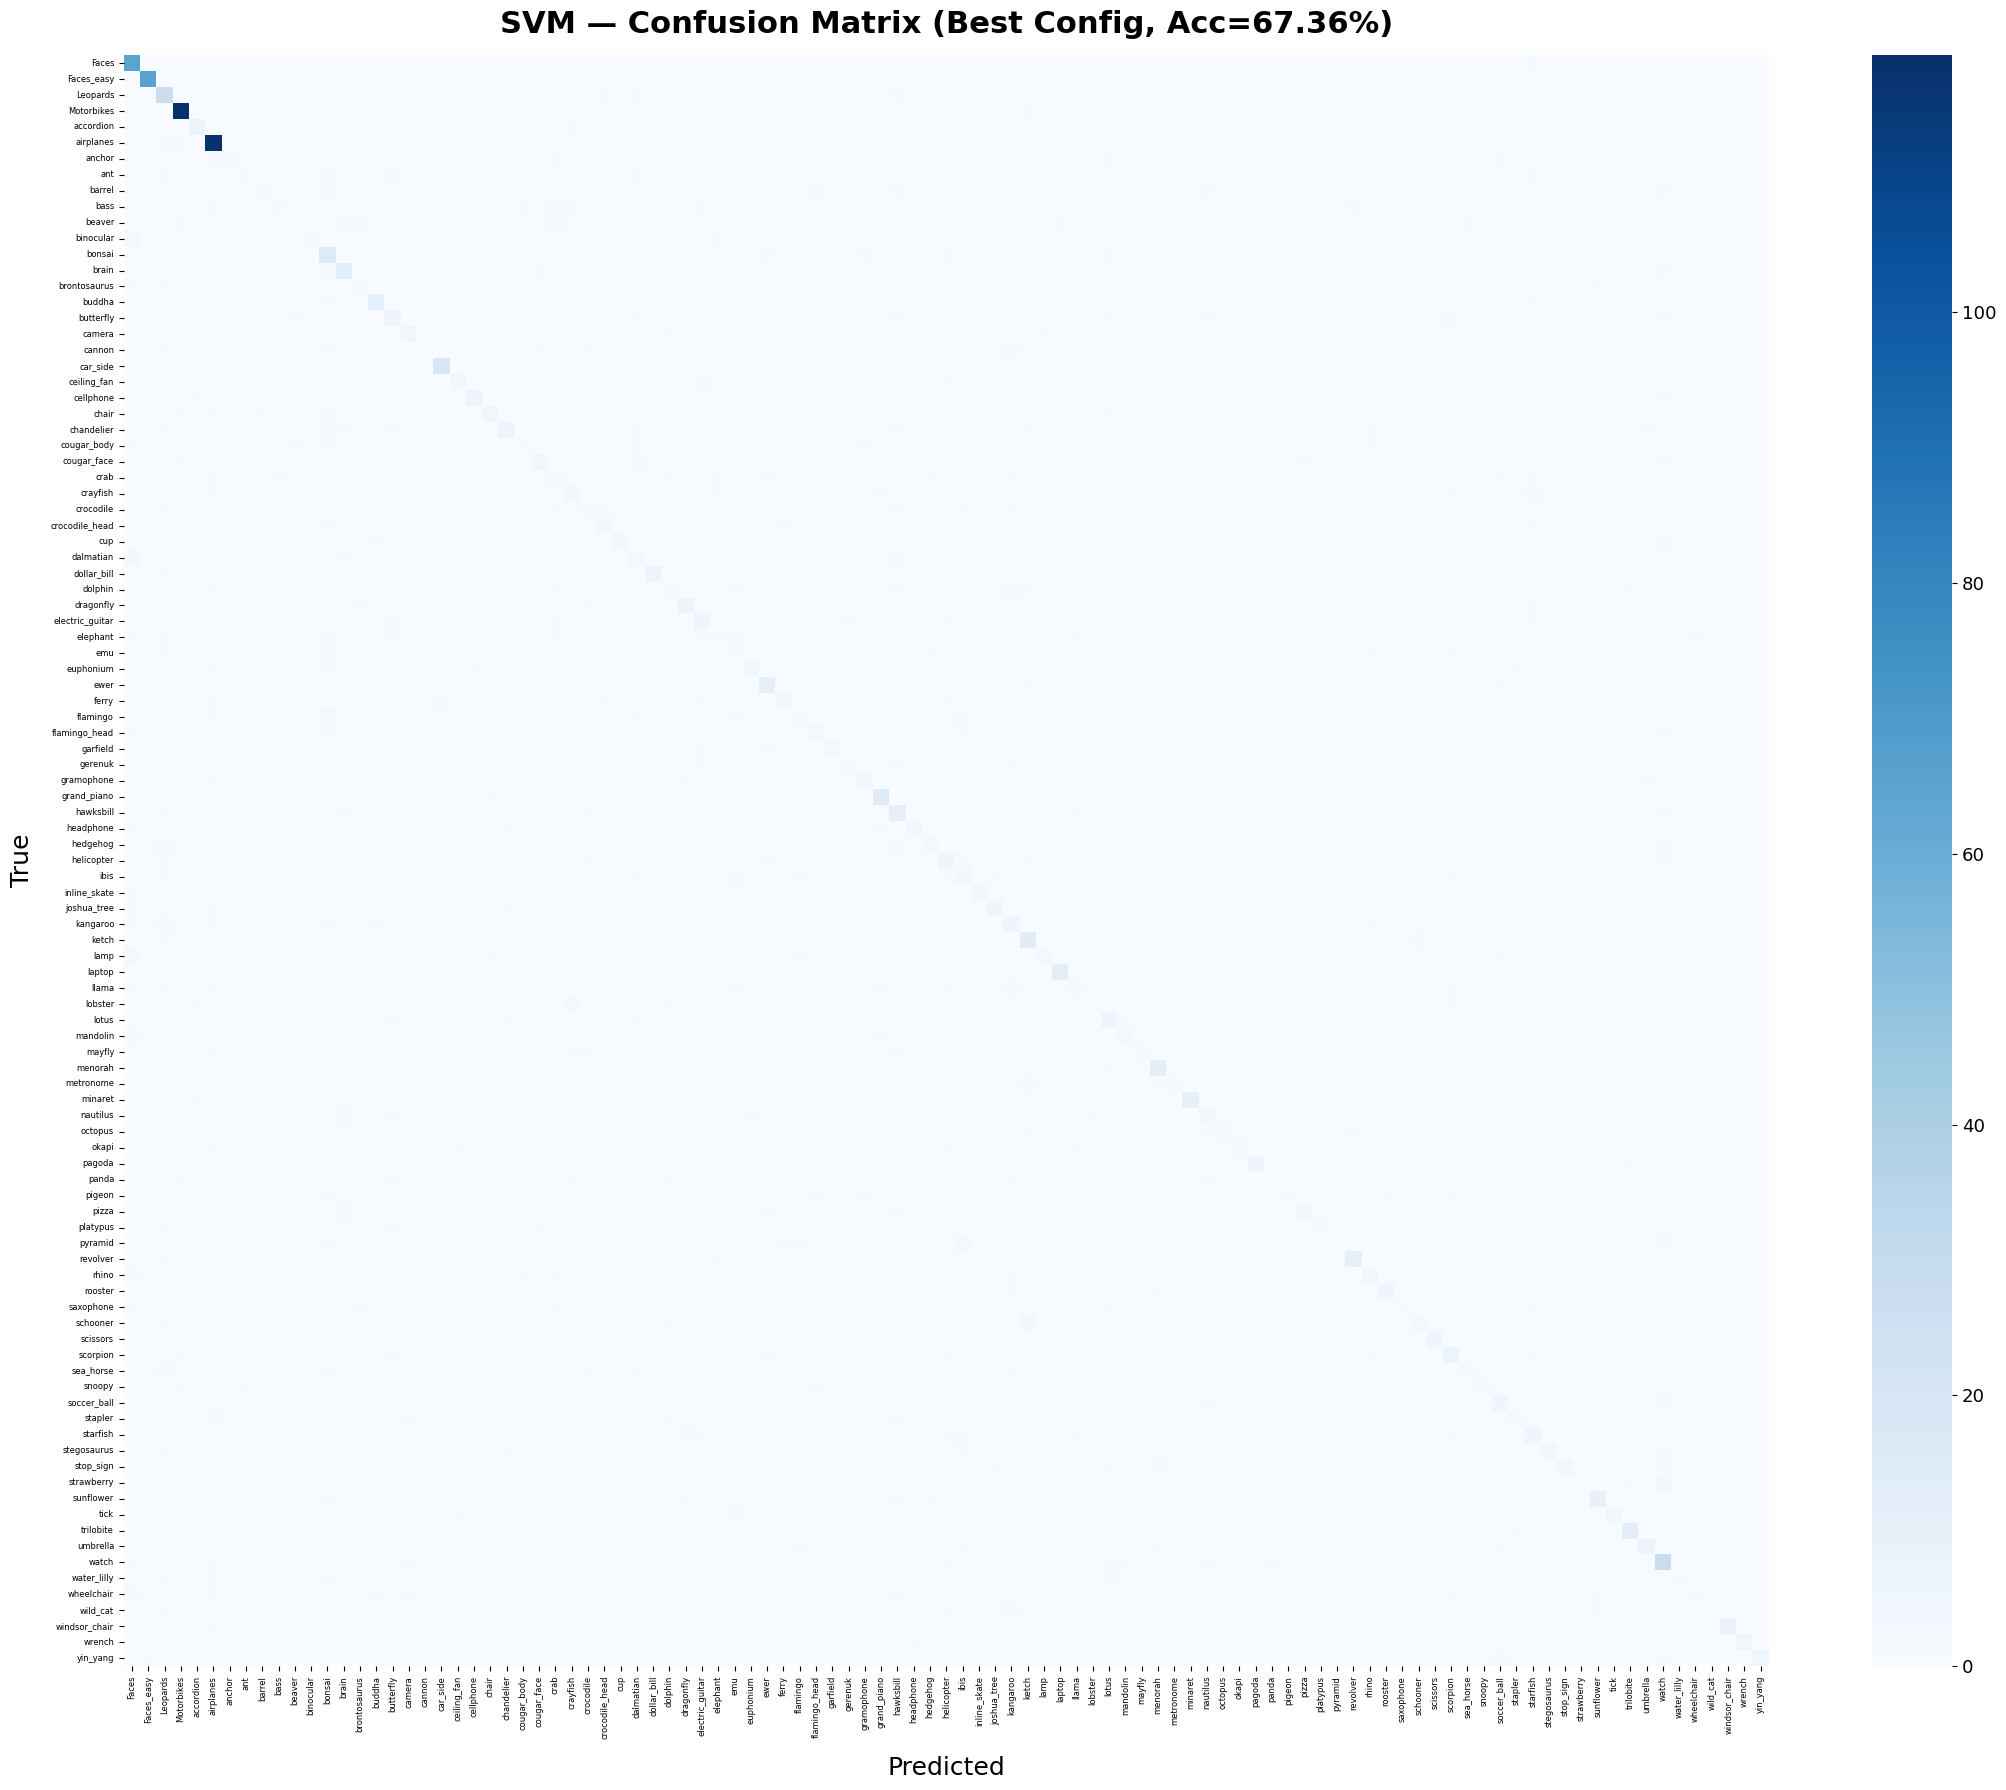

Saved confusion matrix for svm ✓


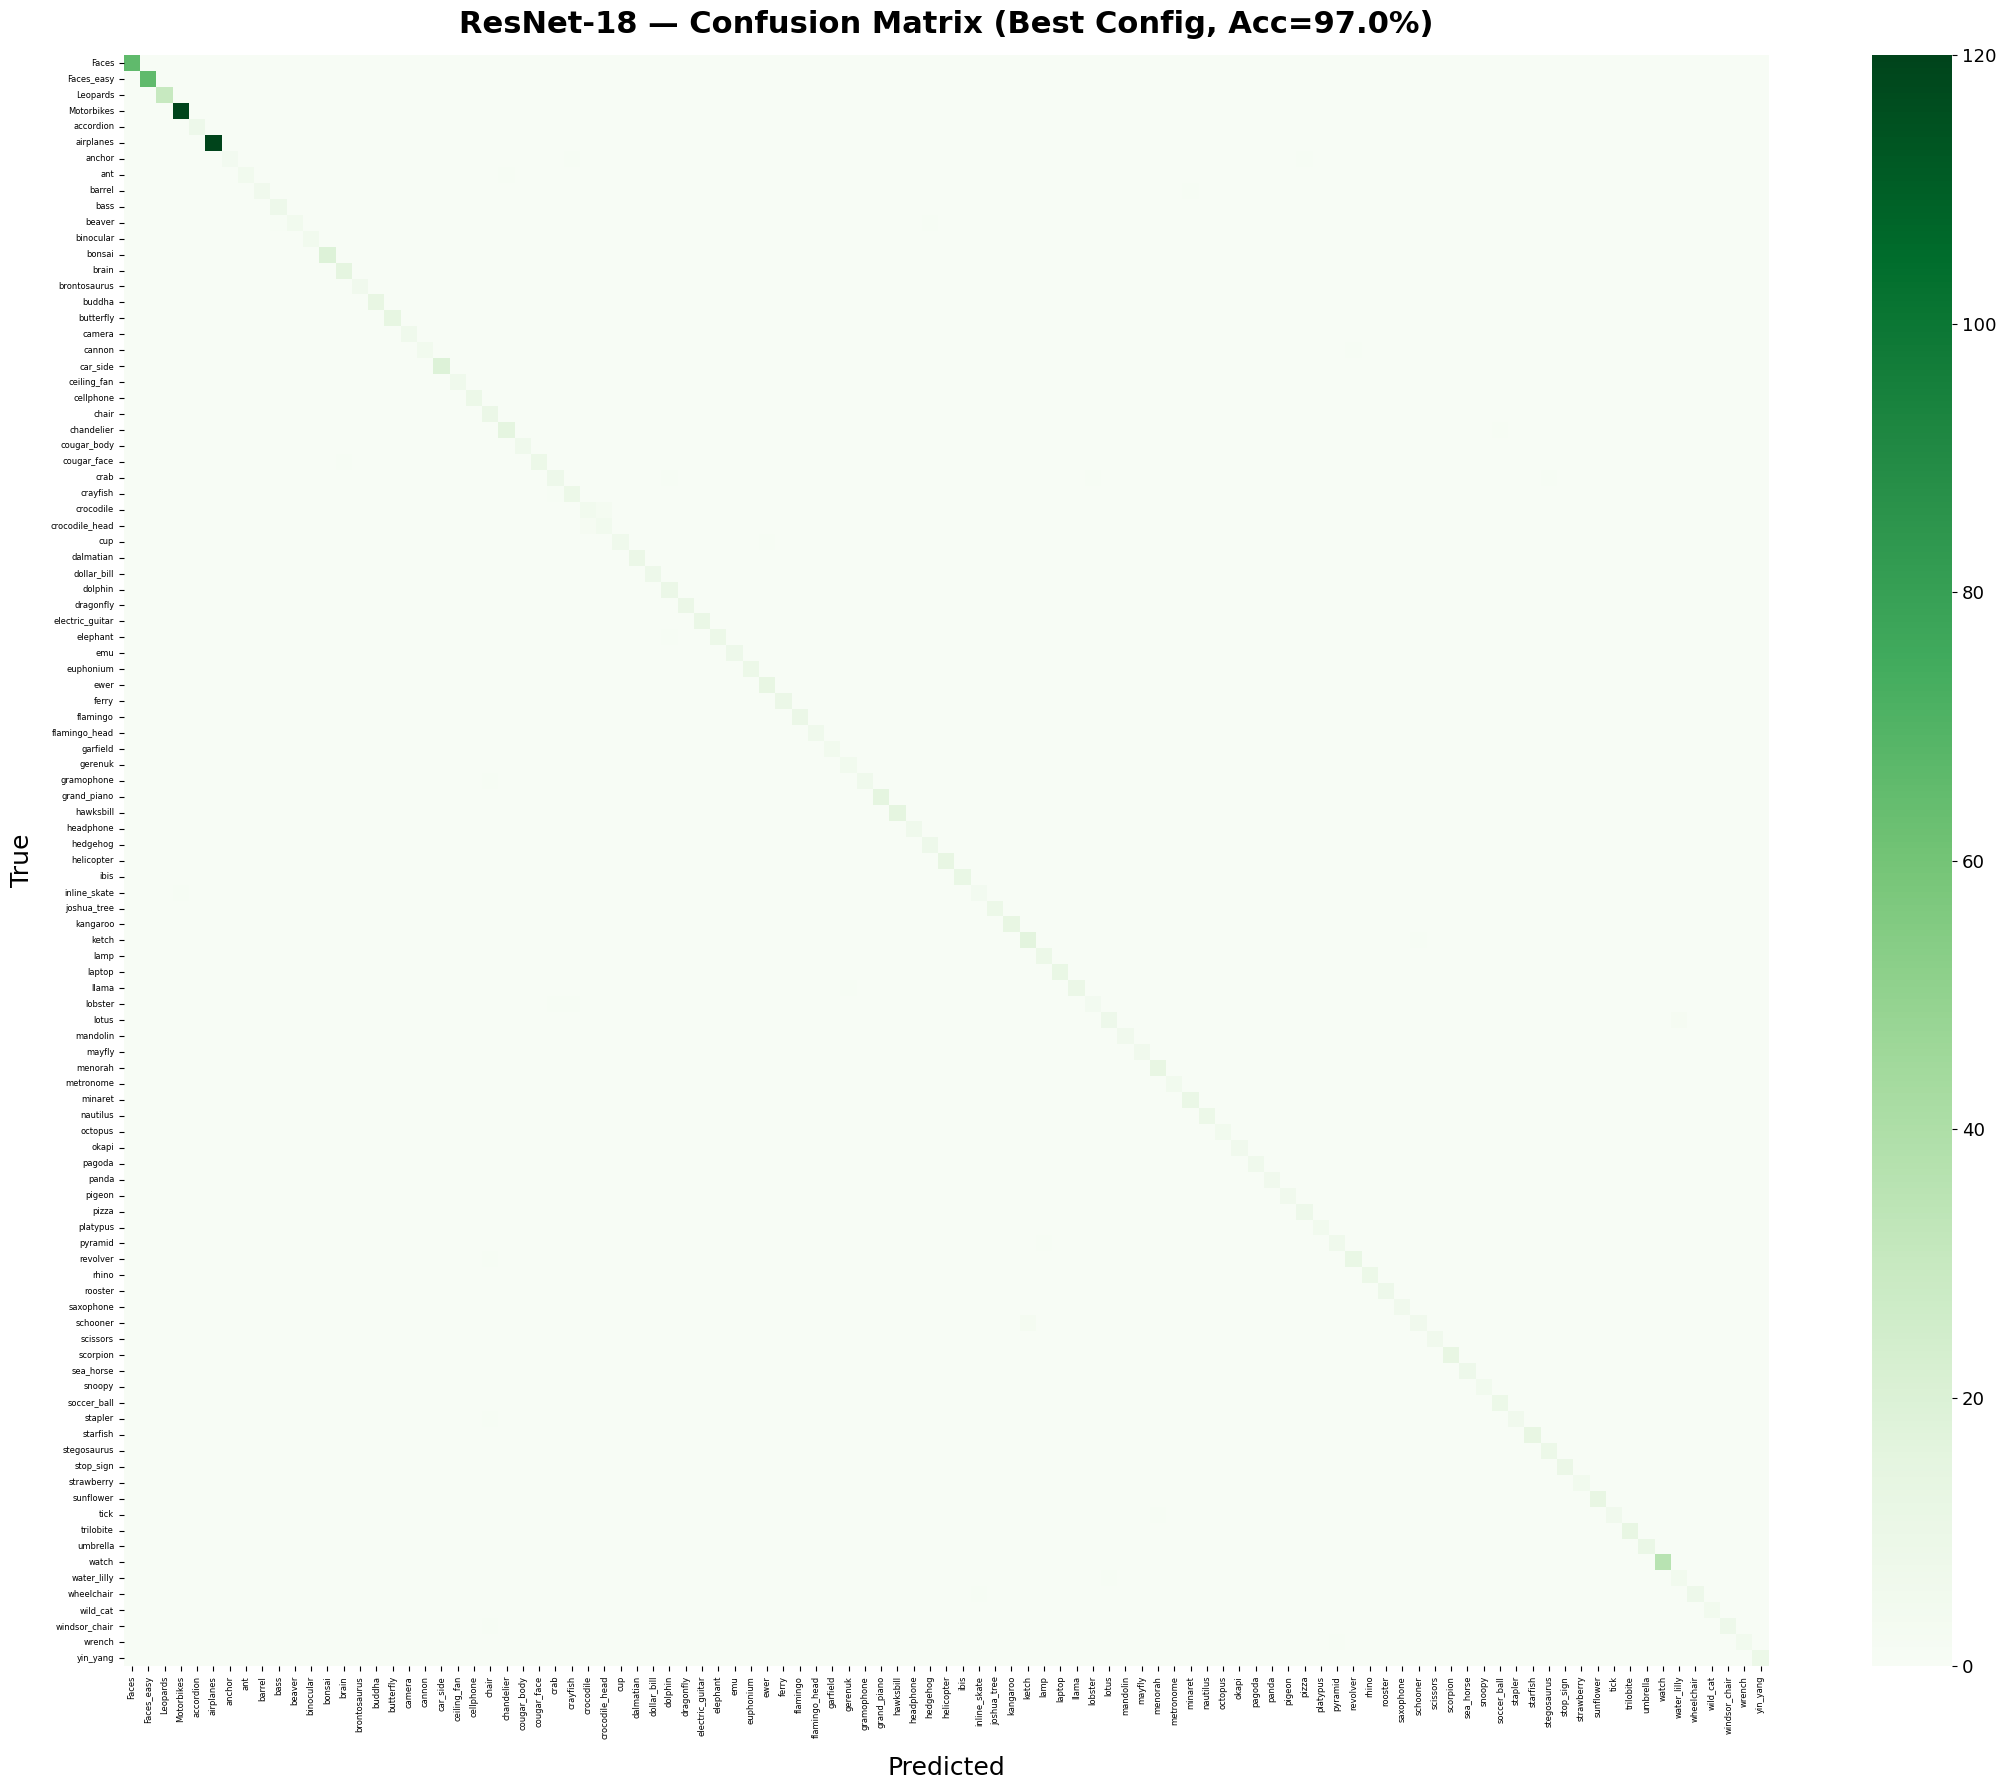

Saved confusion matrix for resnet18 ✓


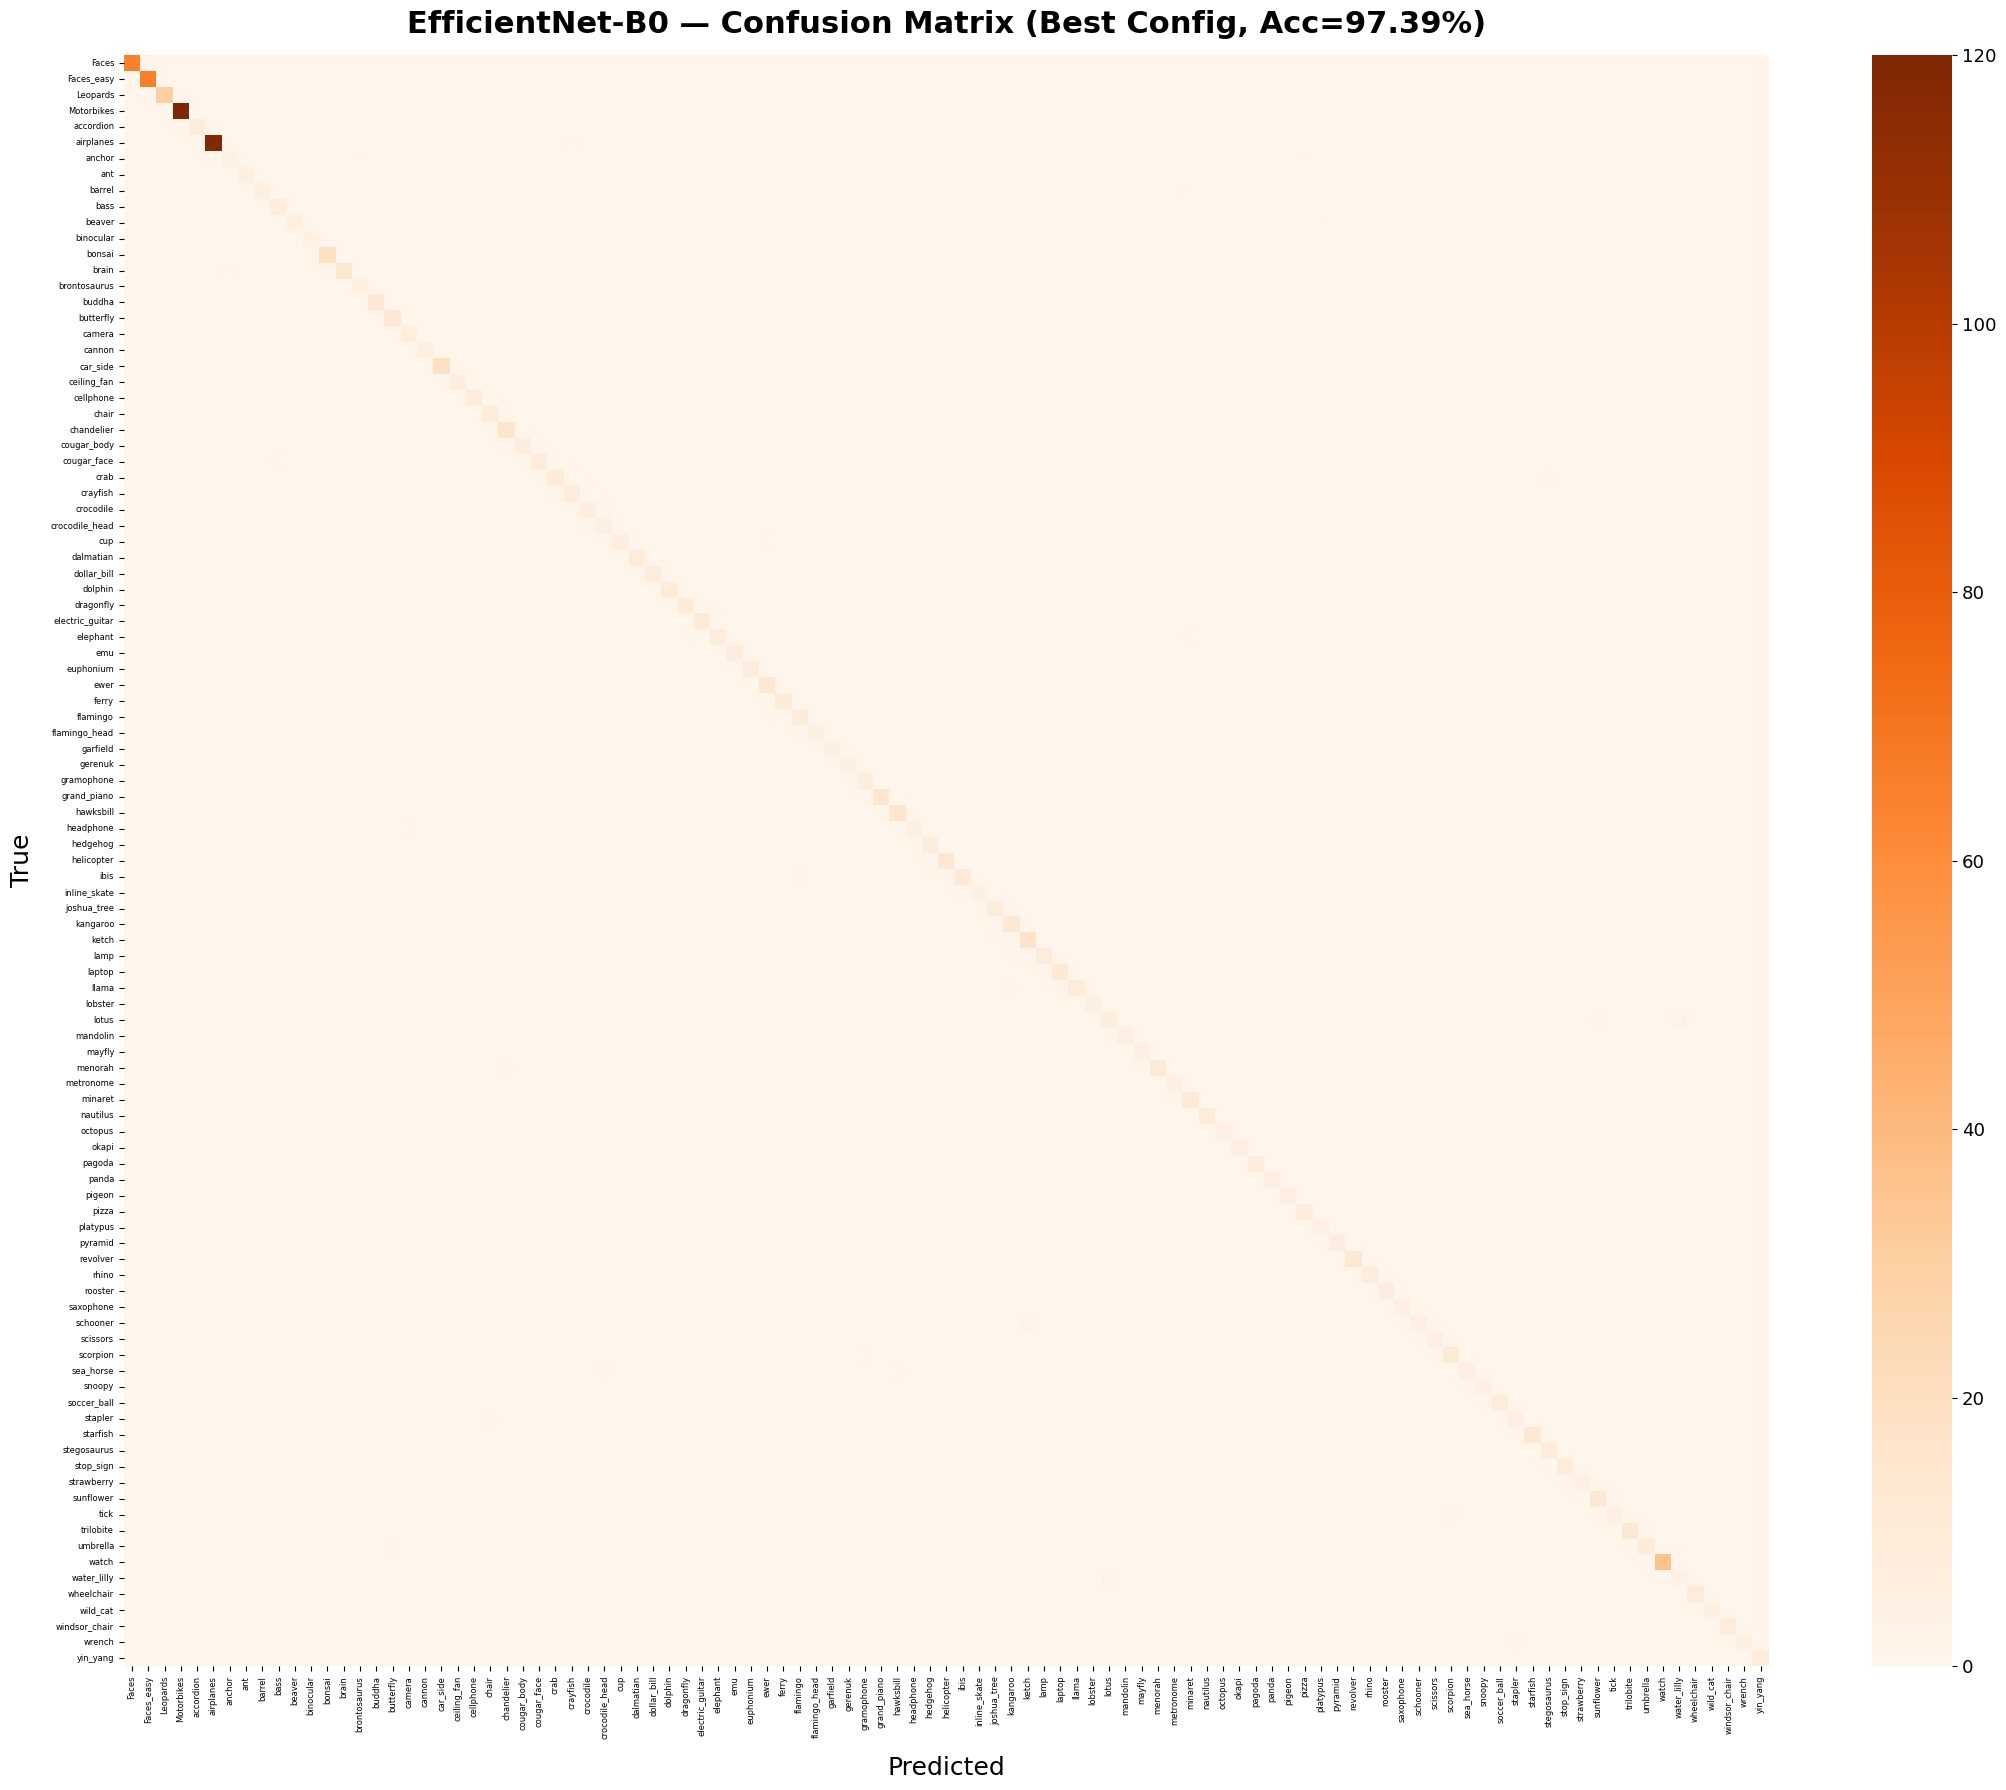

Saved confusion matrix for efficientnet_b0 ✓


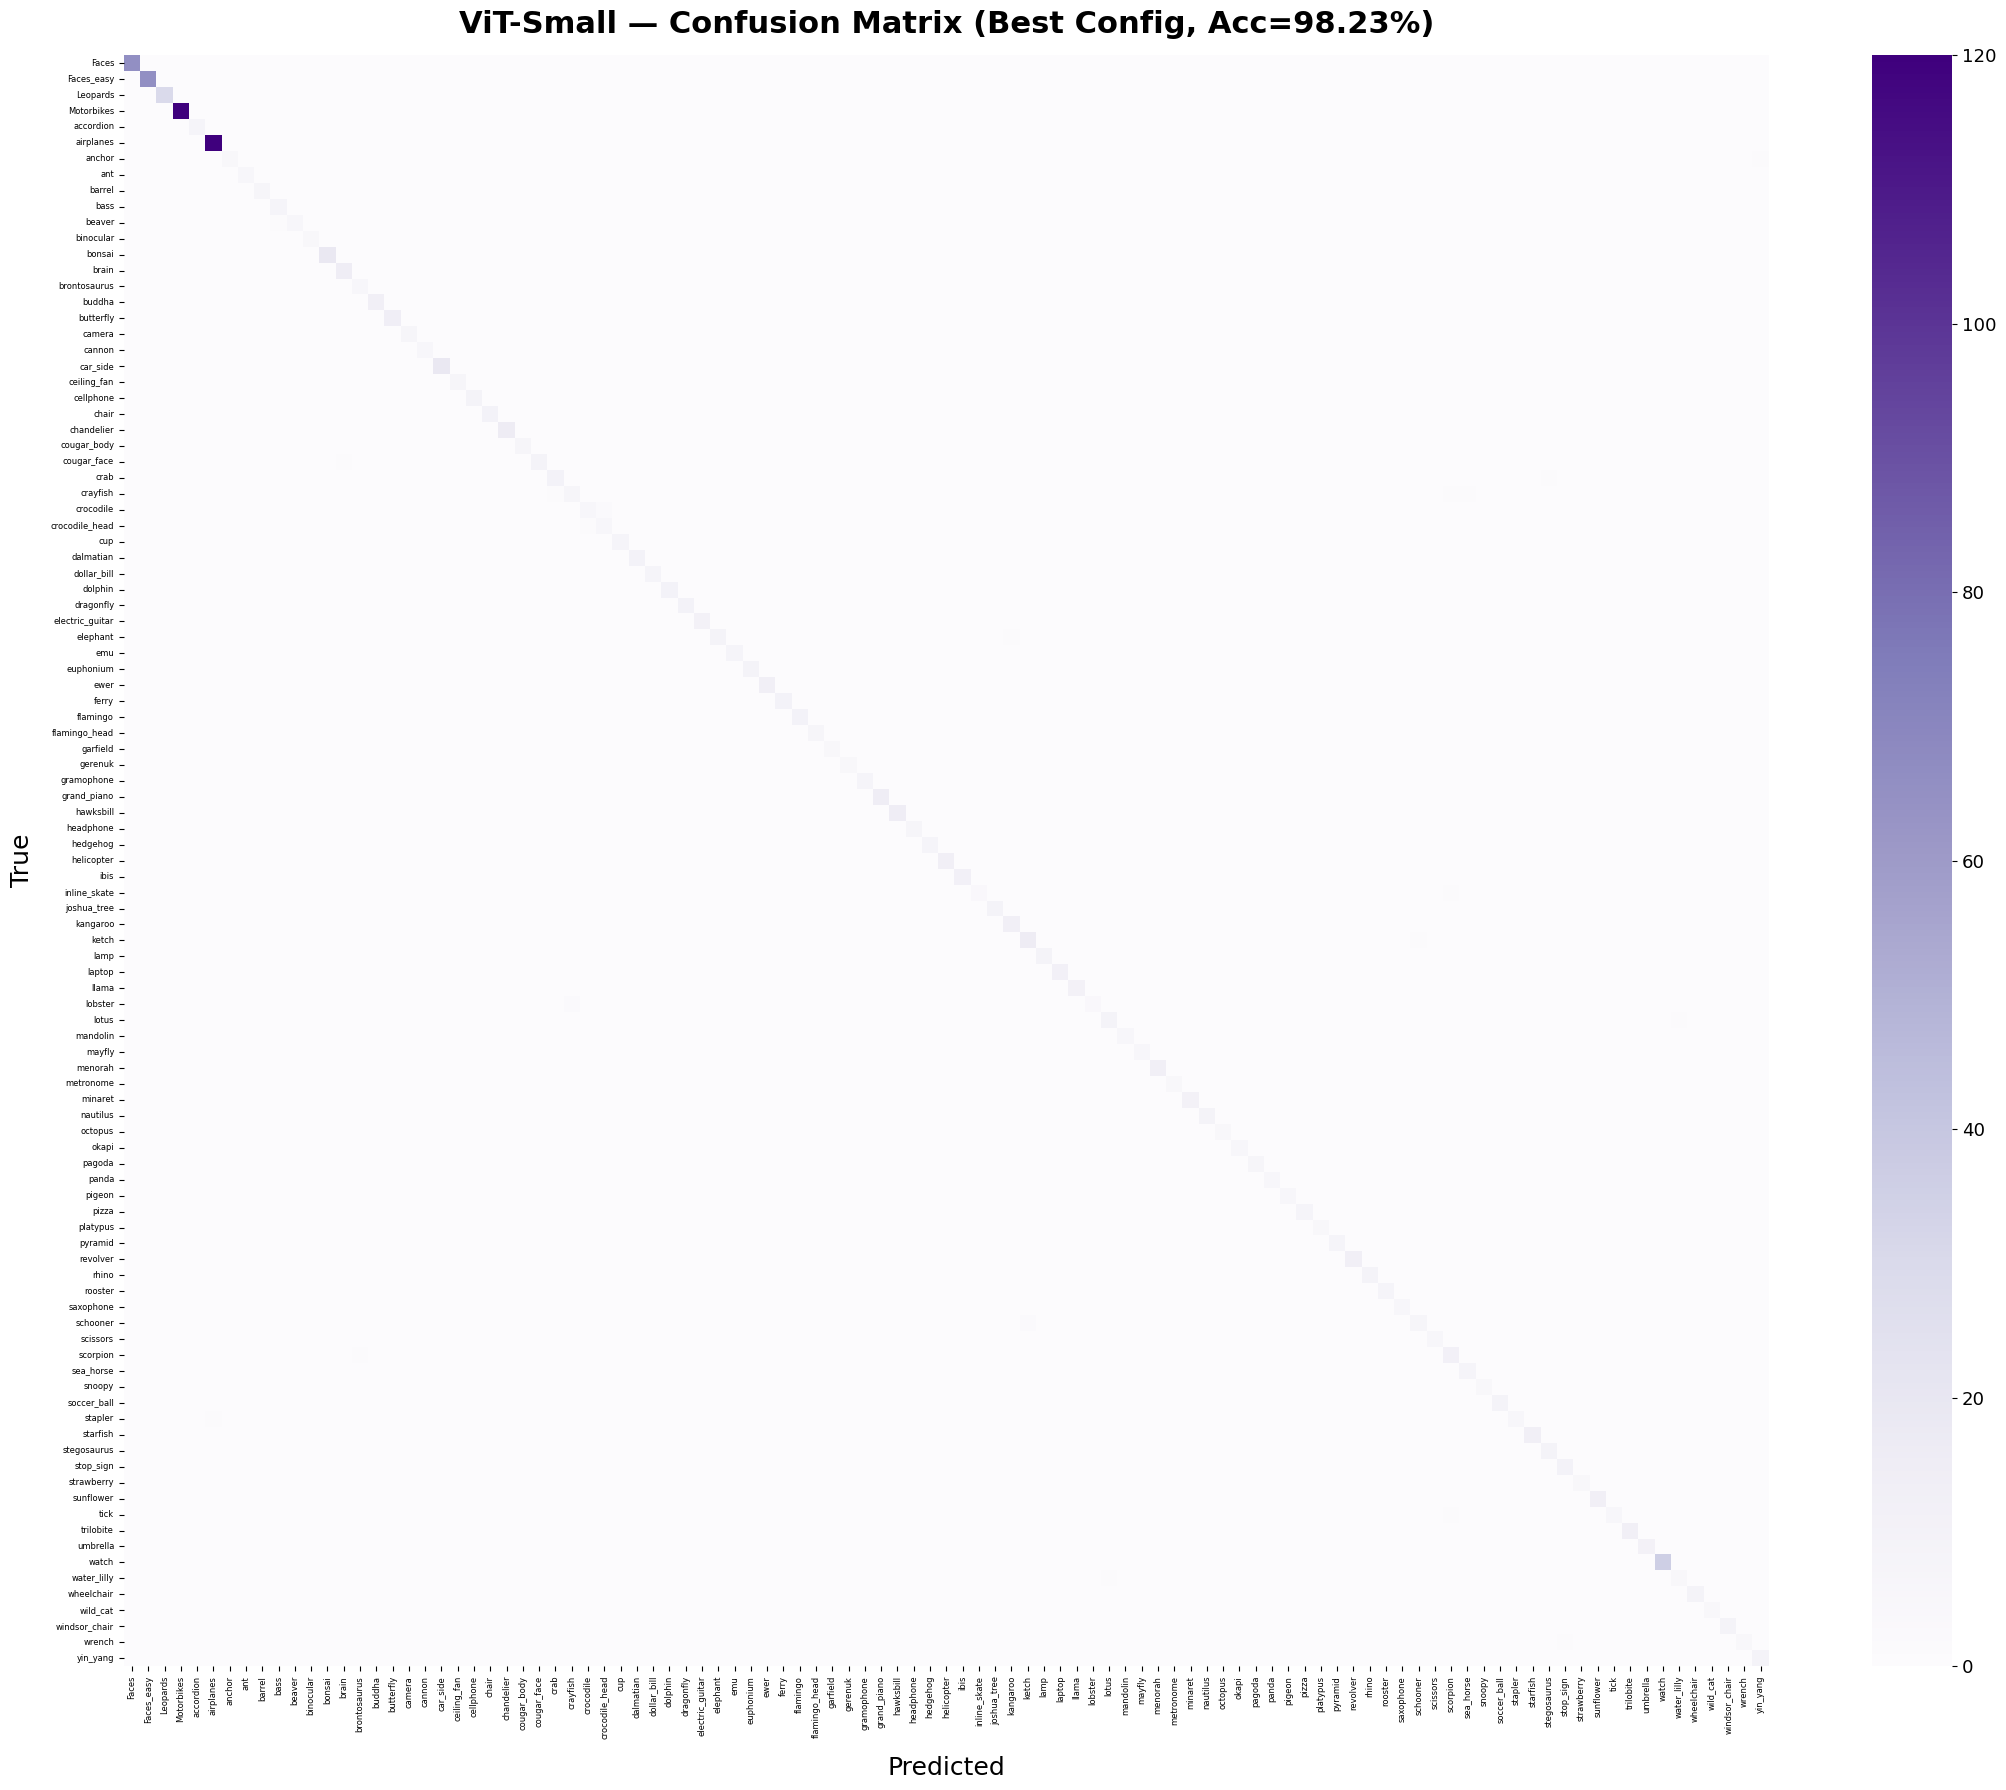

Saved confusion matrix for vit_small ✓


In [16]:
# Confusion Matrix for Best Config of Each Model

MODEL_LABELS = {"svm": "SVM", "resnet18": "ResNet-18",
                "efficientnet_b0": "EfficientNet-B0", "vit_small": "ViT-Small"}

for model_name in ["svm", "resnet18", "efficientnet_b0", "vit_small"]:
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        continue

    best_key = subset.iloc[0]["run_key"]
    cm_data  = np.array(all_results[best_key]["confusion_matrix"])

    fig, ax = plt.subplots(figsize=(22, 18))

    cmap = {"svm": "Blues", "resnet18": "Greens",
            "efficientnet_b0": "Oranges", "vit_small": "Purples"}

    sns.heatmap(cm_data, annot=False, fmt="d",
                cmap=cmap.get(model_name, "Blues"),
                xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax)

    ax.set_xlabel("Predicted", fontsize=18, labelpad=12)
    ax.set_ylabel("True",      fontsize=18, labelpad=12)

    acc = subset.iloc[0]["test_acc_%"]
    ax.set_title(
        f"{MODEL_LABELS[model_name]} — Confusion Matrix (Best Config, Acc={acc}%)",
        fontsize=22, fontweight="bold", pad=16
    )

    ax.tick_params(axis="x", labelsize=6, rotation=90)
    ax.tick_params(axis="y", labelsize=6, rotation=0)

    # Colorbar label size
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_best_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved confusion matrix for {model_name} ✓")

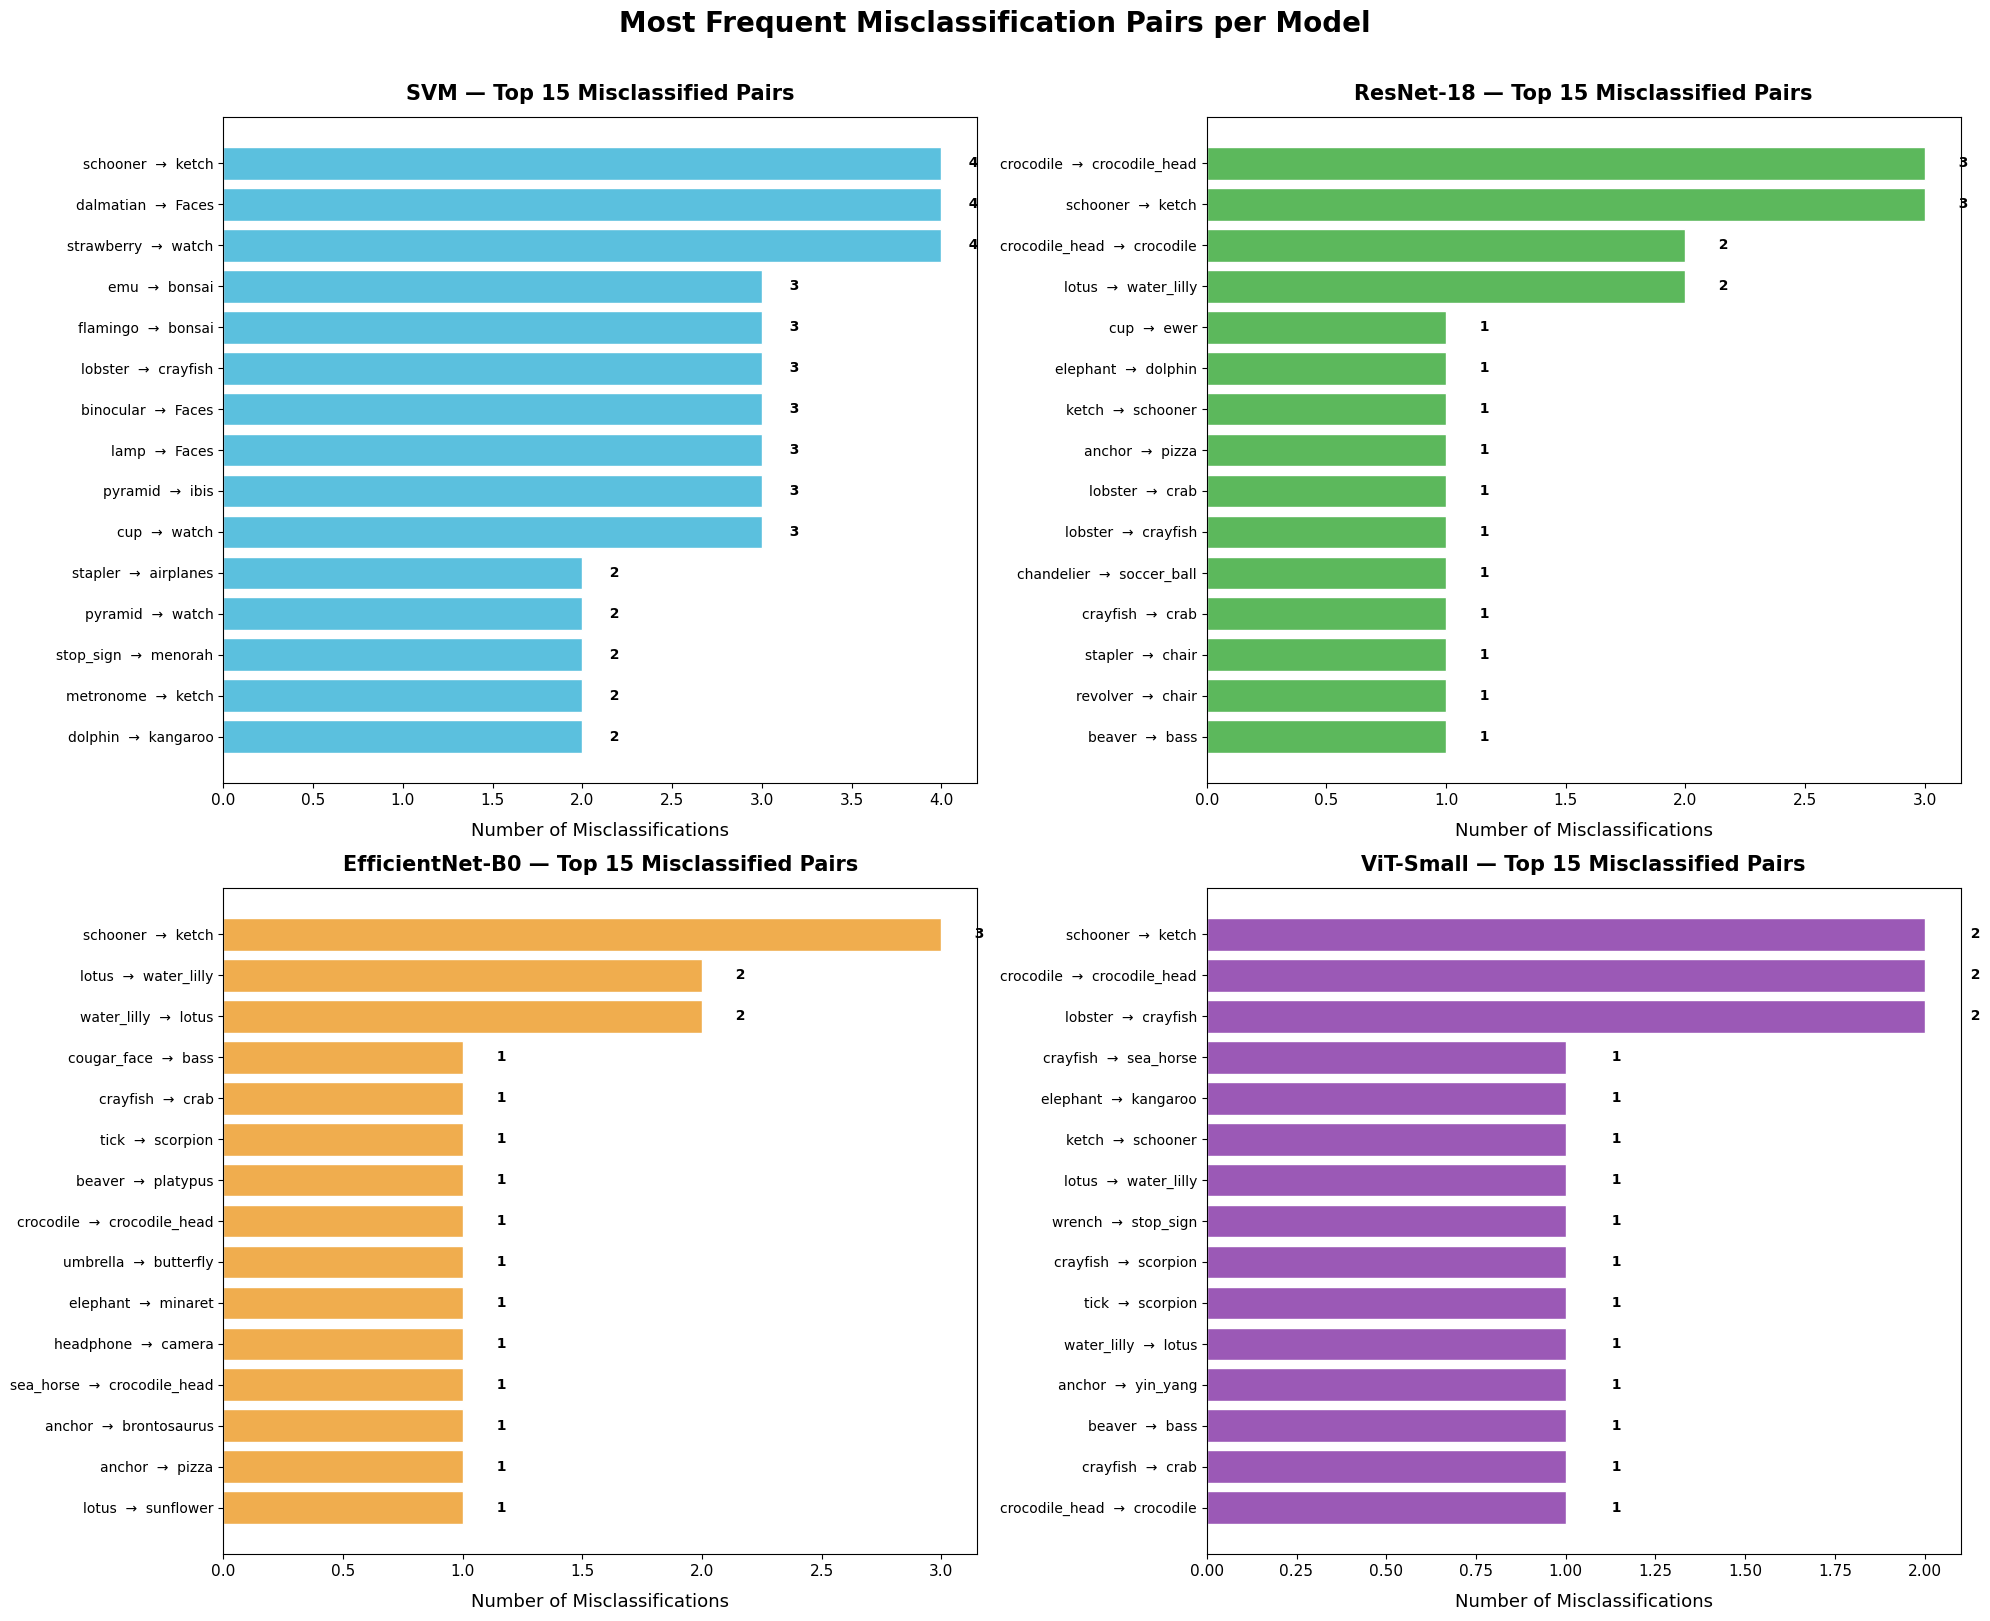

Saved: top_misclassified_pairs.png ✓


In [18]:
# Show the most frequent specific misclassifications as a horizontal bar chart

# Top-N Misclassified Pairs

color_map = {"svm": "#5bc0de", "resnet18": "#5cb85c",
             "efficientnet_b0": "#f0ad4e", "vit_small": "#9b59b6"}

MODEL_LABELS = {"svm": "SVM", "resnet18": "ResNet-18",
                "efficientnet_b0": "EfficientNet-B0", "vit_small": "ViT-Small"}

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, model_name in enumerate(["svm", "resnet18", "efficientnet_b0", "vit_small"]):
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        continue

    cm_data = np.array(all_results[subset.iloc[0]["run_key"]]["confusion_matrix"])
    np.fill_diagonal(cm_data, 0)  # zero out diagonal to focus on errors only

    # Get top 15 misclassified pairs
    flat_idx    = np.argsort(cm_data.flatten())[::-1][:15]
    true_idx    = flat_idx // cm_data.shape[0]
    pred_idx    = flat_idx  % cm_data.shape[0]
    counts      = cm_data[true_idx, pred_idx]
    pair_labels = [f"{le.classes_[t]}  →  {le.classes_[p]}"
                   for t, p in zip(true_idx, pred_idx)]

    color = color_map.get(model_name, "gray")
    axes[i].barh(range(len(counts))[::-1], counts, color=color, edgecolor="white")

    for j, (val, label) in enumerate(zip(counts, pair_labels)):
        axes[i].text(val + 0.1, len(counts) - 1 - j, f"  {val}",
                     va="center", fontsize=10, fontweight="bold")

    axes[i].set_yticks(range(len(pair_labels)))
    axes[i].set_yticklabels(pair_labels[::-1], fontsize=10)
    axes[i].set_xlabel("Number of Misclassifications", fontsize=13, labelpad=10)
    axes[i].set_title(
        f"{MODEL_LABELS[model_name]} — Top 15 Misclassified Pairs",
        fontsize=15, fontweight="bold", pad=12
    )
    axes[i].tick_params(axis="x", labelsize=11)

plt.suptitle("Most Frequent Misclassification Pairs per Model",
             fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "top_misclassified_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top_misclassified_pairs.png ✓")

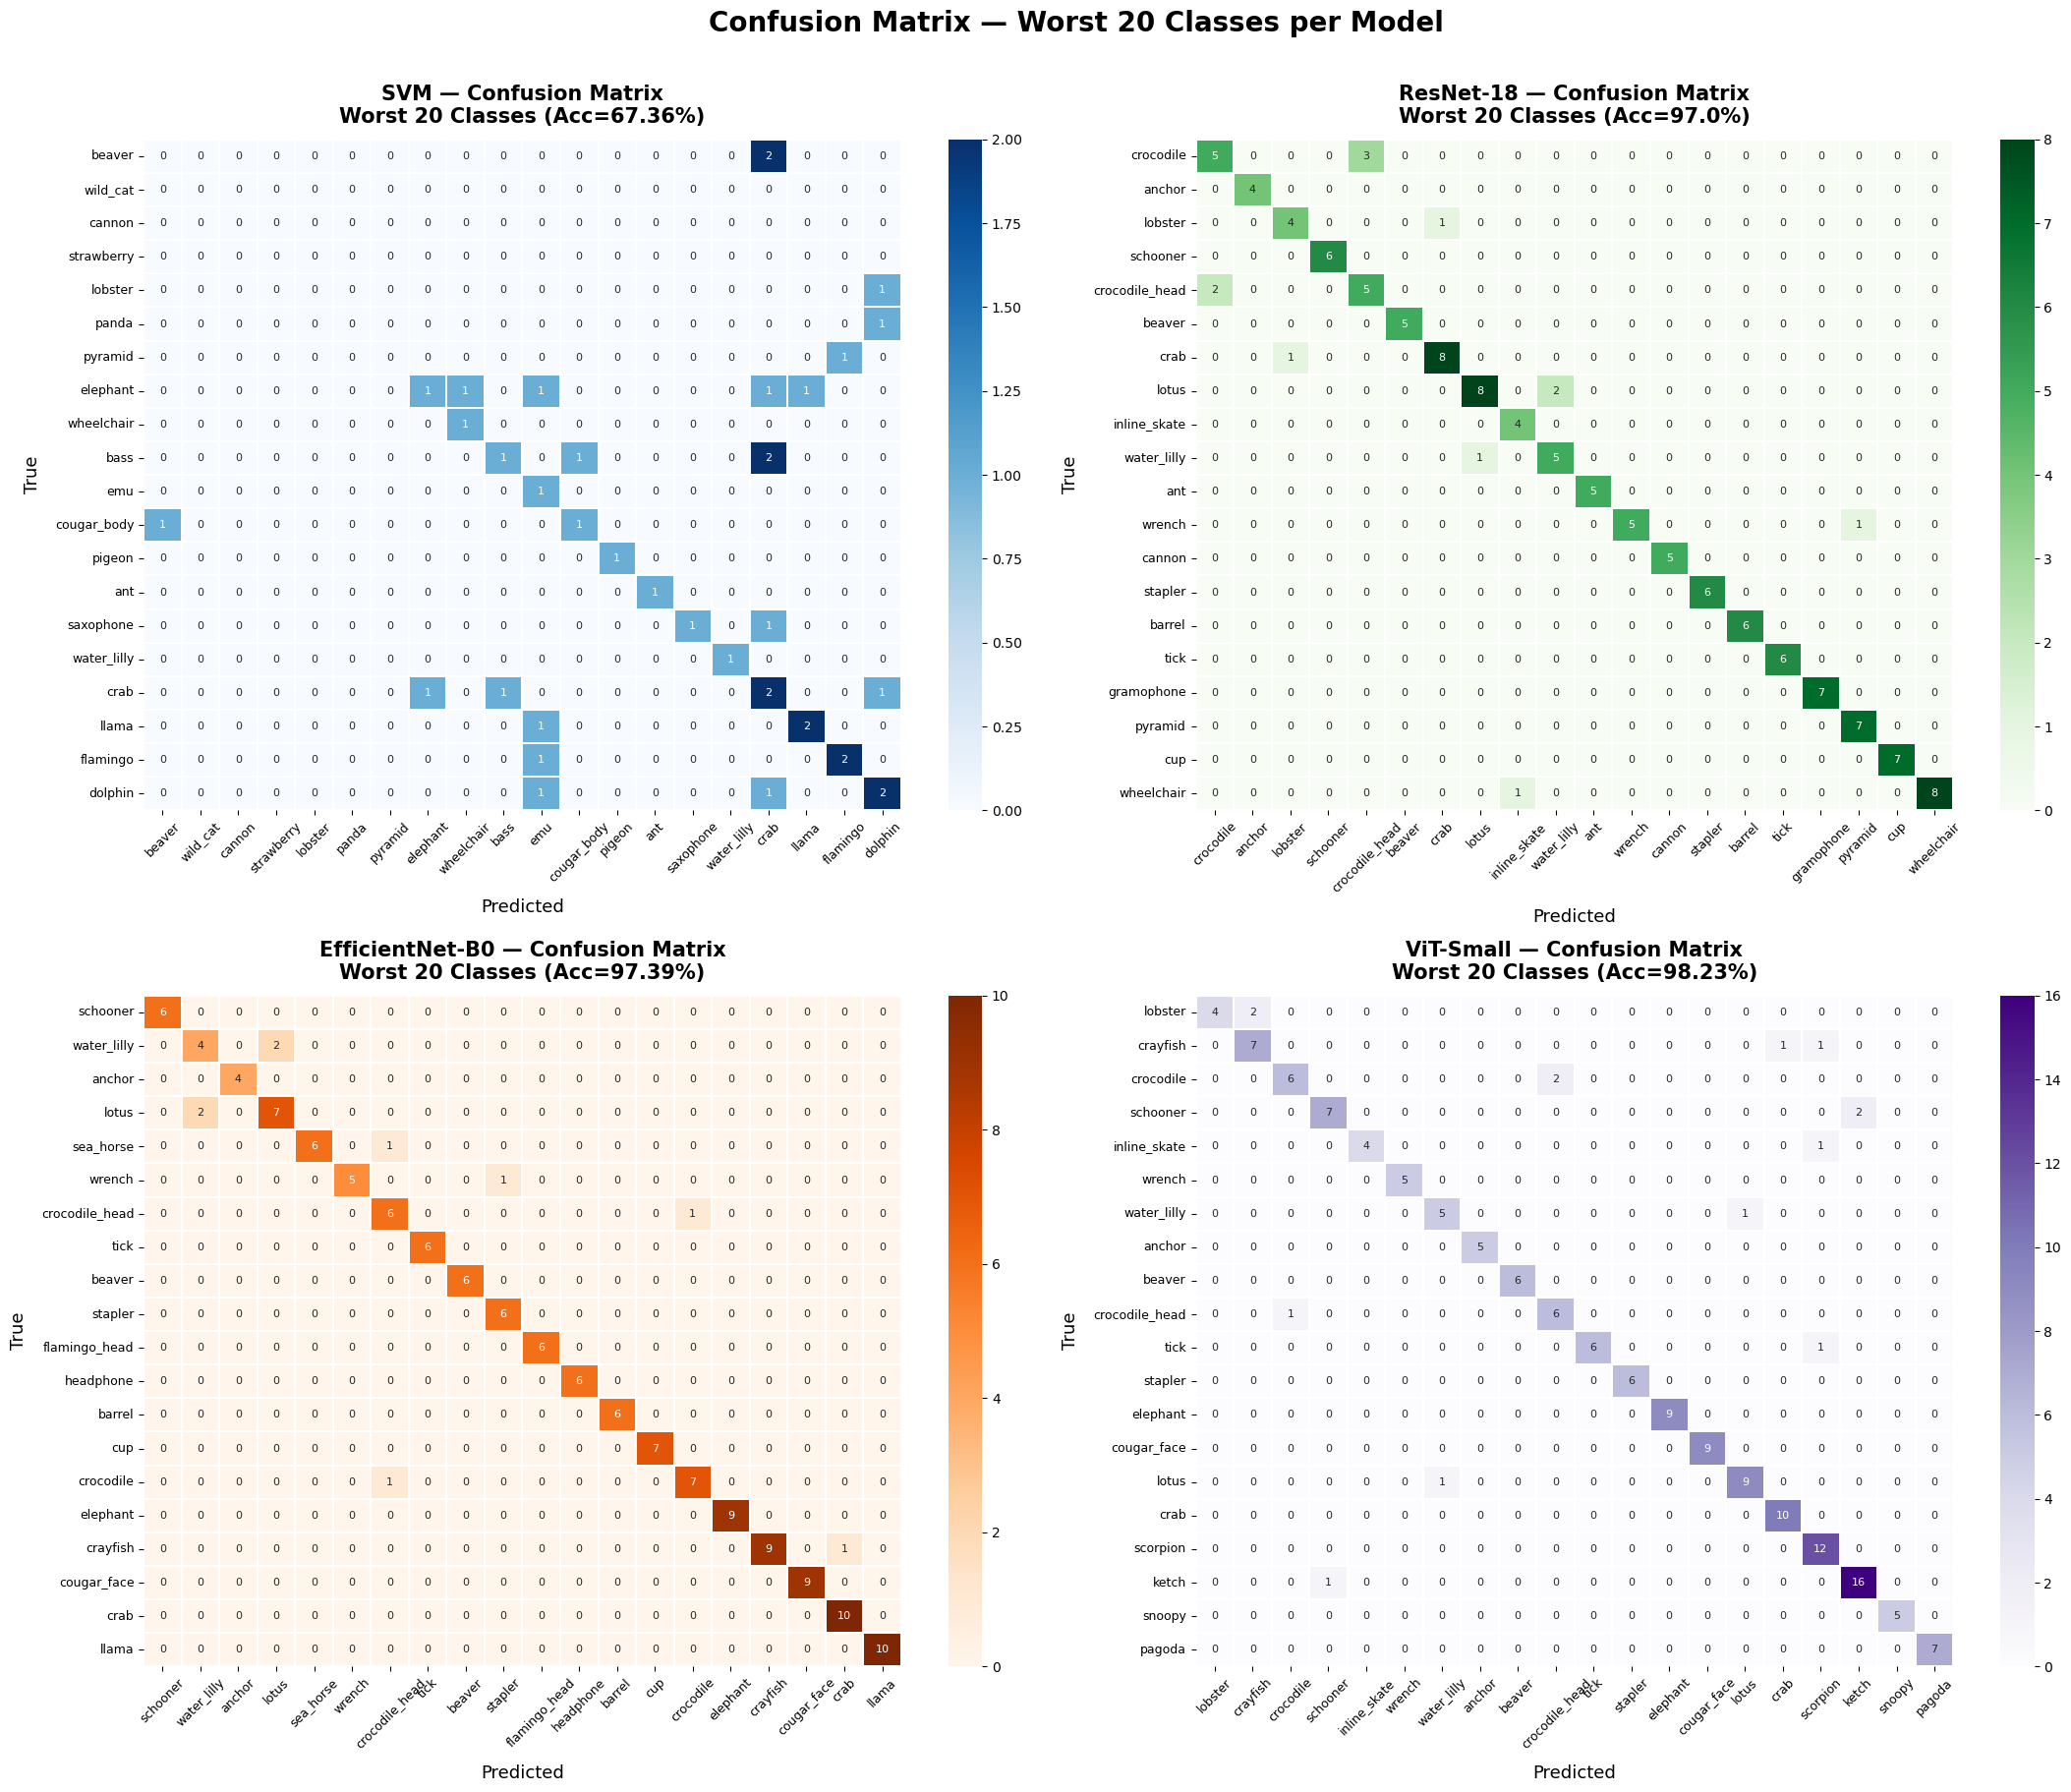

Saved: confusion_matrix_worst_classes.png ✓


In [19]:
# Zoom into only the worst-performing classes
N = 20  # show only bottom 20 classes by accuracy

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

cmap = {"svm": "Blues", "resnet18": "Greens",
        "efficientnet_b0": "Oranges", "vit_small": "Purples"}

for i, model_name in enumerate(["svm", "resnet18", "efficientnet_b0", "vit_small"]):
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        continue

    best_key = subset.iloc[0]["run_key"]
    cm_data  = np.array(all_results[best_key]["confusion_matrix"])
    pca      = np.array(all_results[best_key]["per_class_acc"])

    # Select N worst classes by per-class accuracy
    worst_idx   = np.argsort(pca)[:N]
    cm_subset   = cm_data[np.ix_(worst_idx, worst_idx)]
    class_names = le.classes_[worst_idx]

    sns.heatmap(cm_subset, annot=True, fmt="d",
                cmap=cmap.get(model_name, "Blues"),
                xticklabels=class_names,
                yticklabels=class_names,
                ax=axes[i], linewidths=0.3,
                annot_kws={"size": 8})

    acc = subset.iloc[0]["test_acc_%"]
    axes[i].set_title(
        f"{MODEL_LABELS[model_name]} — Confusion Matrix\nWorst {N} Classes (Acc={acc}%)",
        fontsize=15, fontweight="bold", pad=12
    )
    axes[i].set_xlabel("Predicted", fontsize=13, labelpad=10)
    axes[i].set_ylabel("True",      fontsize=13, labelpad=10)
    axes[i].tick_params(axis="x", labelsize=9, rotation=45)
    axes[i].tick_params(axis="y", labelsize=9, rotation=0)

plt.suptitle(f"Confusion Matrix — Worst {N} Classes per Model",
             fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_worst_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_worst_classes.png ✓")

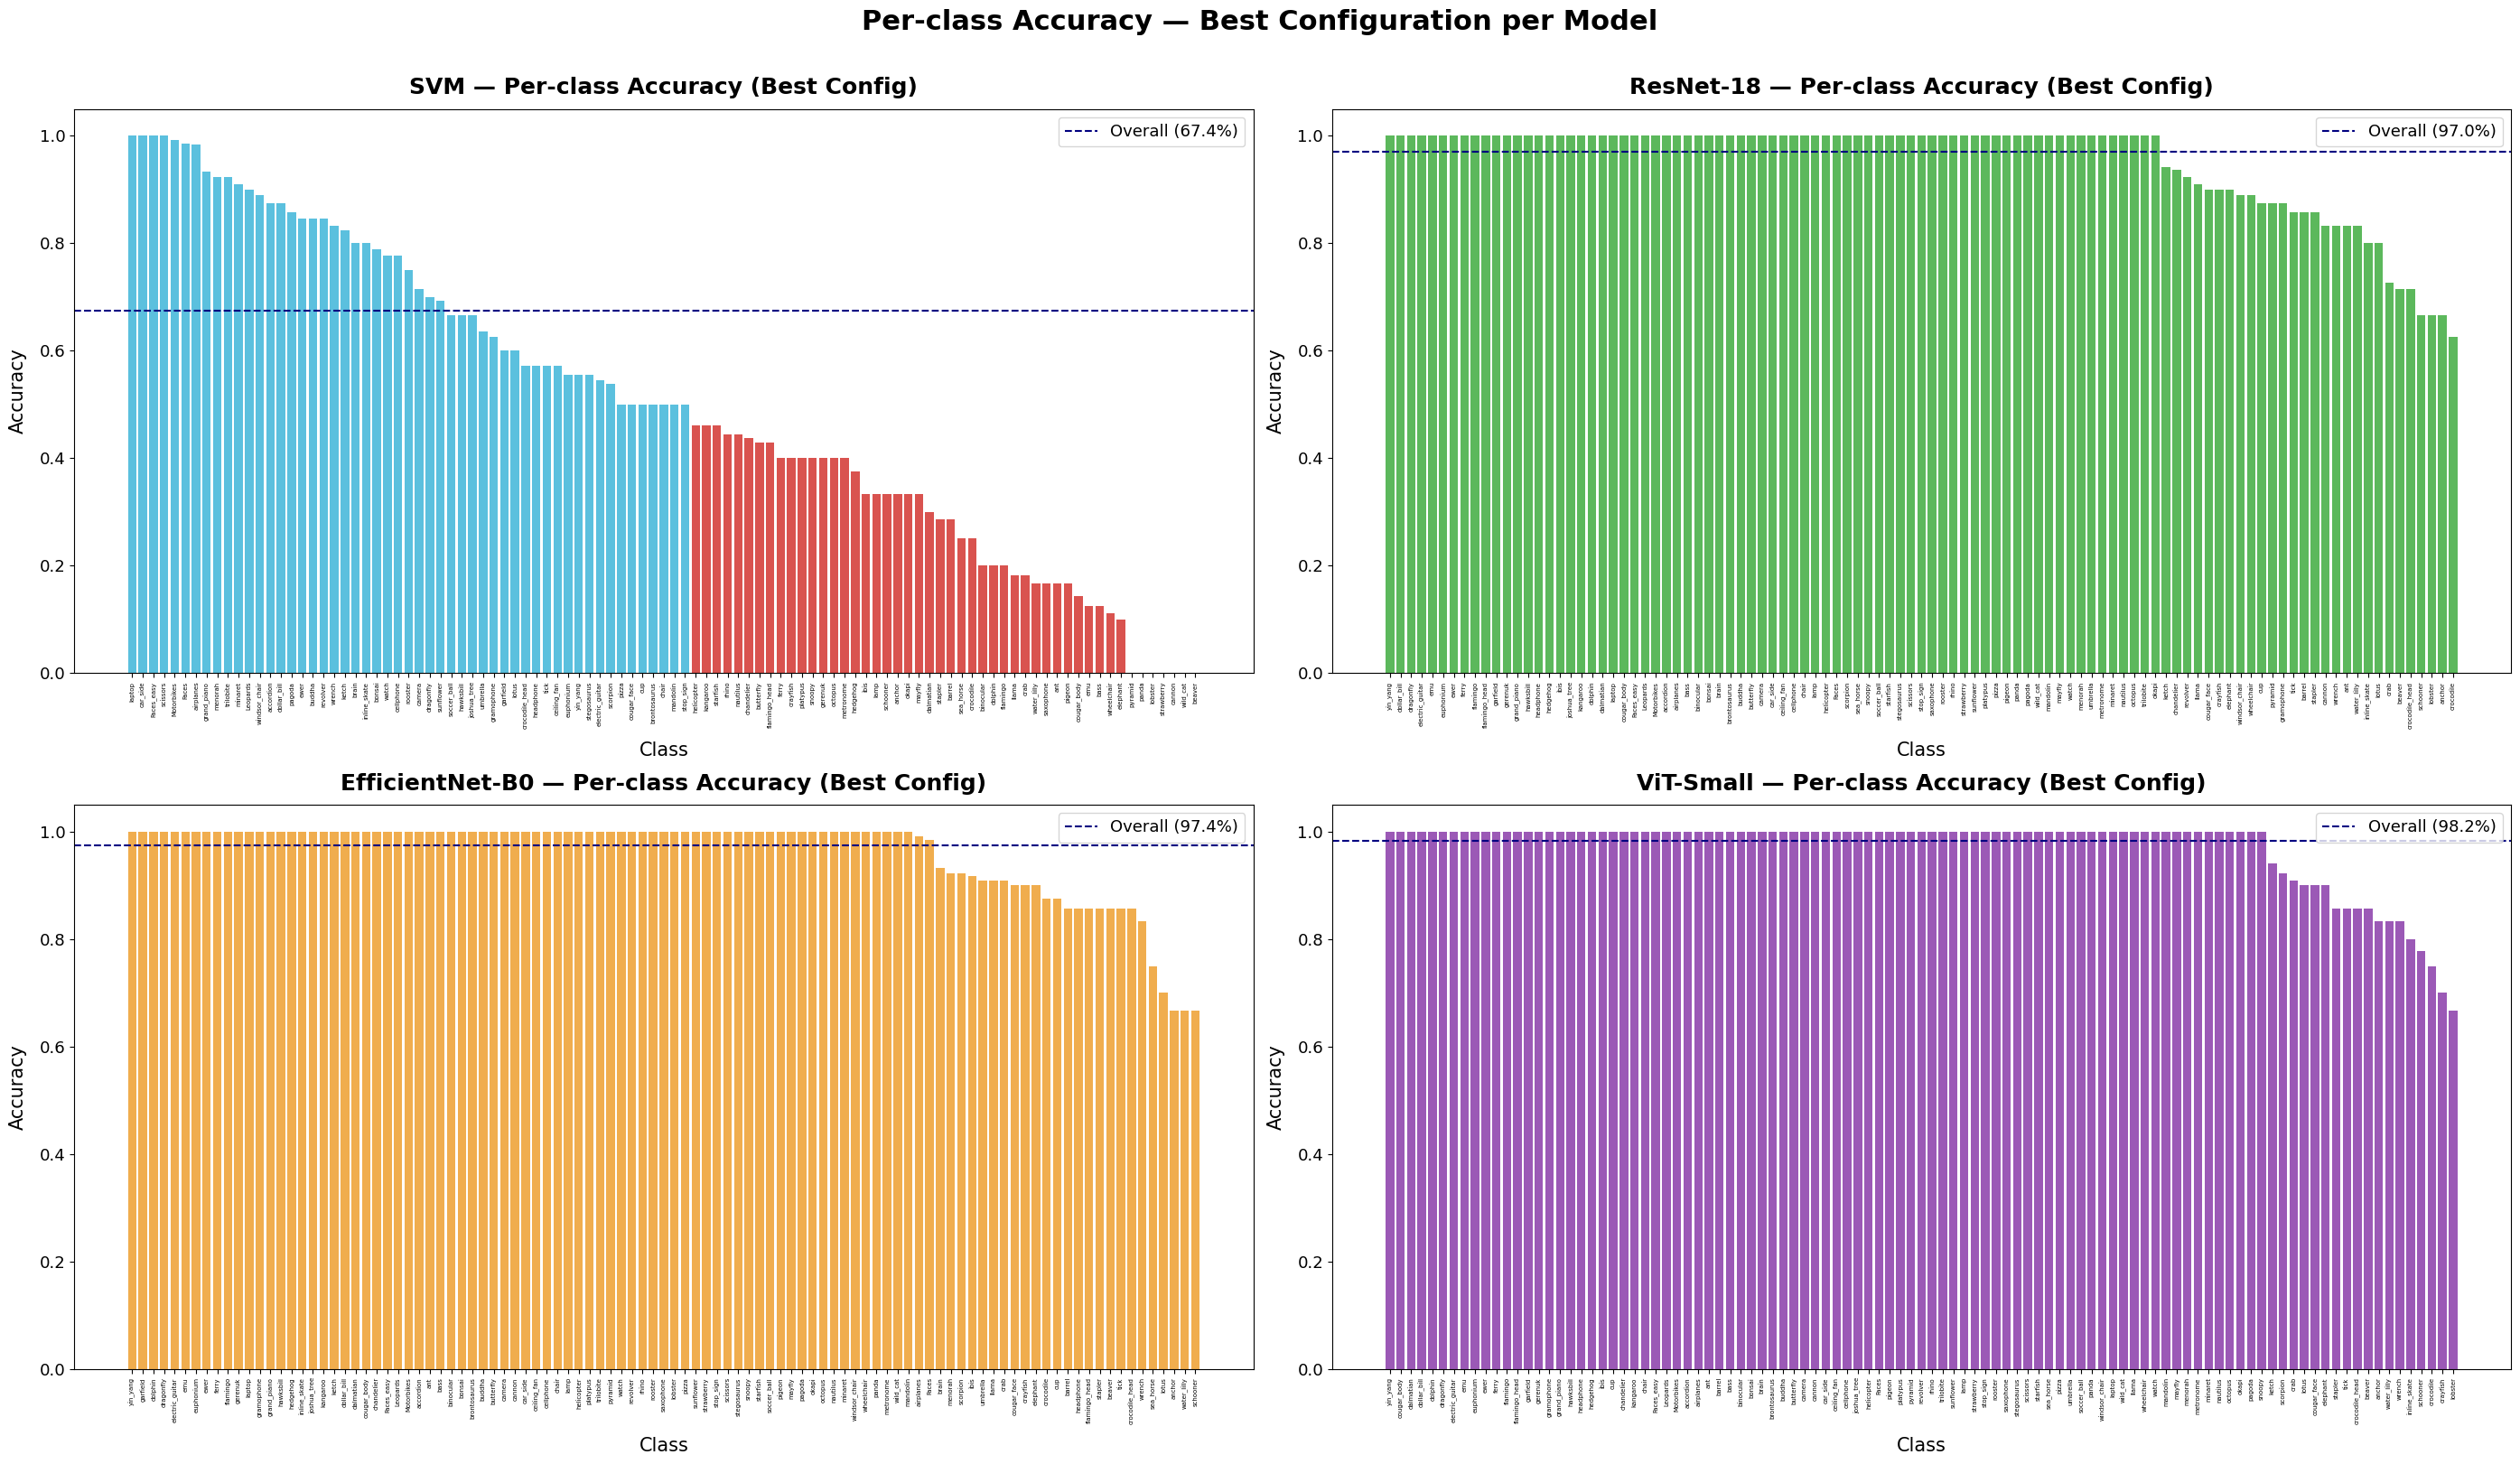

Saved: all_models_per_class_accuracy.png ✓


In [20]:
# Per-class Accuracy for Best Config of Each Model

MODEL_LABELS = {"svm": "SVM", "resnet18": "ResNet-18",
                "efficientnet_b0": "EfficientNet-B0", "vit_small": "ViT-Small"}

fig, axes = plt.subplots(2, 2, figsize=(28, 16))
axes = axes.flatten()

color_map = {"svm": "#5bc0de", "resnet18": "#5cb85c",
             "efficientnet_b0": "#f0ad4e", "vit_small": "#9b59b6"}

for i, model_name in enumerate(["svm", "resnet18", "efficientnet_b0", "vit_small"]):
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        axes[i].set_title(f"{MODEL_LABELS[model_name]} — no results", fontsize=16)
        continue

    best_key    = subset.iloc[0]["run_key"]
    pca         = np.array(all_results[best_key]["per_class_acc"])
    overall_acc = subset.iloc[0]["test_acc_%"] / 100

    sorted_idx   = np.argsort(pca)[::-1]
    sorted_pca   = pca[sorted_idx]
    sorted_names = le.classes_[sorted_idx]

    color      = color_map.get(model_name, "gray")
    bar_colors = ["#d9534f" if v < 0.5 else color for v in sorted_pca]

    axes[i].bar(range(len(sorted_pca)), sorted_pca, color=bar_colors)
    axes[i].axhline(overall_acc, color="navy", linestyle="--",
                    label=f"Overall ({overall_acc*100:.1f}%)")

    axes[i].set_title(
        f"{MODEL_LABELS[model_name]} — Per-class Accuracy (Best Config)",
        fontsize=18, fontweight="bold", pad=12
    )
    axes[i].set_ylabel("Accuracy", fontsize=15, labelpad=10)
    axes[i].set_xlabel("Class", fontsize=15, labelpad=10)

    axes[i].set_xticks(range(len(sorted_names)))
    axes[i].set_xticklabels(sorted_names, rotation=90, fontsize=5)
    axes[i].tick_params(axis="y", labelsize=13)

    axes[i].legend(fontsize=13)

plt.suptitle("Per-class Accuracy — Best Configuration per Model",
             fontsize=22, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "all_models_per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_models_per_class_accuracy.png ✓")

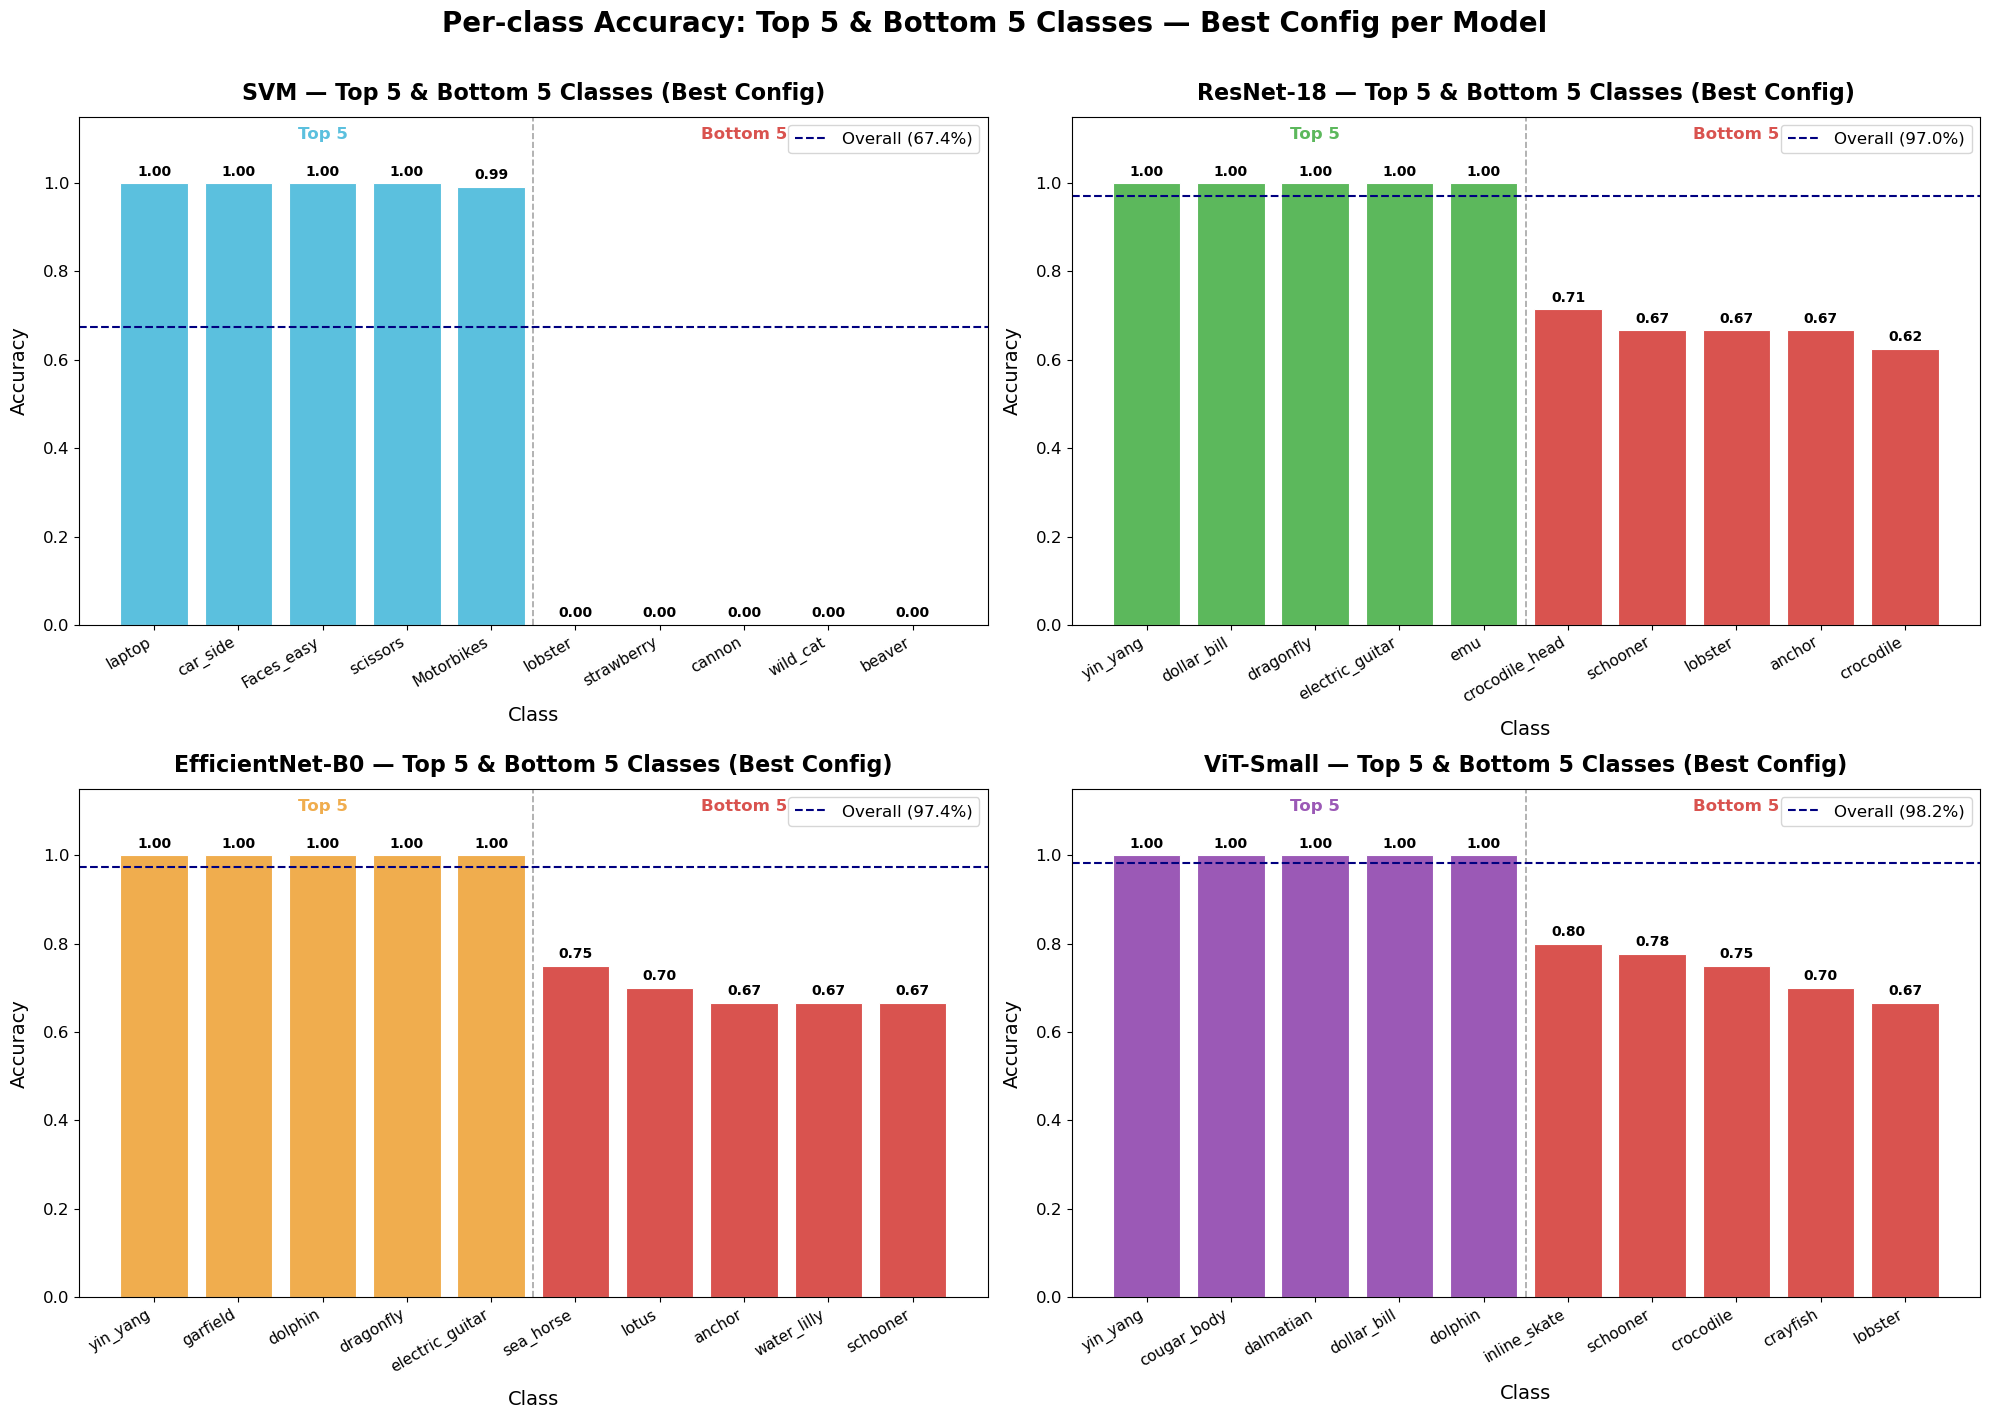

Saved: top_bottom5_per_class_accuracy.png ✓


In [21]:
# Per-class Accuracy — Top 5 and Bottom 5 per Model

MODEL_LABELS = {"svm": "SVM", "resnet18": "ResNet-18",
                "efficientnet_b0": "EfficientNet-B0", "vit_small": "ViT-Small"}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

color_map = {"svm": "#5bc0de", "resnet18": "#5cb85c",
             "efficientnet_b0": "#f0ad4e", "vit_small": "#9b59b6"}

for i, model_name in enumerate(["svm", "resnet18", "efficientnet_b0", "vit_small"]):
    subset = results_df[results_df["model"] == model_name]
    if subset.empty:
        axes[i].set_title(f"{MODEL_LABELS[model_name]} — no results", fontsize=16)
        continue

    best_key    = subset.iloc[0]["run_key"]
    pca         = np.array(all_results[best_key]["per_class_acc"])
    overall_acc = subset.iloc[0]["test_acc_%"] / 100

    sorted_idx   = np.argsort(pca)[::-1]
    sorted_pca   = pca[sorted_idx]
    sorted_names = le.classes_[sorted_idx]

    # Top 5 and bottom 5
    top_idx    = list(range(5))
    bot_idx    = list(range(len(sorted_pca) - 5, len(sorted_pca)))
    sel_idx    = top_idx + bot_idx
    sel_pca    = sorted_pca[sel_idx]
    sel_names  = sorted_names[sel_idx]

    color      = color_map.get(model_name, "gray")
    bar_colors = (
        [color] * 5 +          # top 5 — model color
        ["#d9534f"] * 5        # bottom 5 — red
    )

    x = np.arange(len(sel_names))
    bars = axes[i].bar(x, sel_pca, color=bar_colors, edgecolor="white", linewidth=0.8)

    # Value annotations on each bar
    for bar, val in zip(bars, sel_pca):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

    # Divider line between top 5 and bottom 5
    axes[i].axvline(x=4.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

    # Overall accuracy reference line
    axes[i].axhline(overall_acc, color="navy", linestyle="--", linewidth=1.5,
                    label=f"Overall ({overall_acc*100:.1f}%)")

    axes[i].set_title(
        f"{MODEL_LABELS[model_name]} — Top 5 & Bottom 5 Classes (Best Config)",
        fontsize=16, fontweight="bold", pad=12
    )
    axes[i].set_ylabel("Accuracy", fontsize=14, labelpad=10)
    axes[i].set_xlabel("Class", fontsize=14, labelpad=10)
    axes[i].set_ylim(0, 1.15)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(sel_names, rotation=30, ha="right", fontsize=11)
    axes[i].tick_params(axis="y", labelsize=12)
    axes[i].legend(fontsize=12)

    # Top / Bottom group labels
    axes[i].text(2,   1.10, "Top 5",    ha="center", fontsize=12, color=color,     fontweight="bold")
    axes[i].text(7,   1.10, "Bottom 5", ha="center", fontsize=12, color="#d9534f", fontweight="bold")

plt.suptitle("Per-class Accuracy: Top 5 & Bottom 5 Classes — Best Config per Model",
             fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "top_bottom5_per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top_bottom5_per_class_accuracy.png ✓")

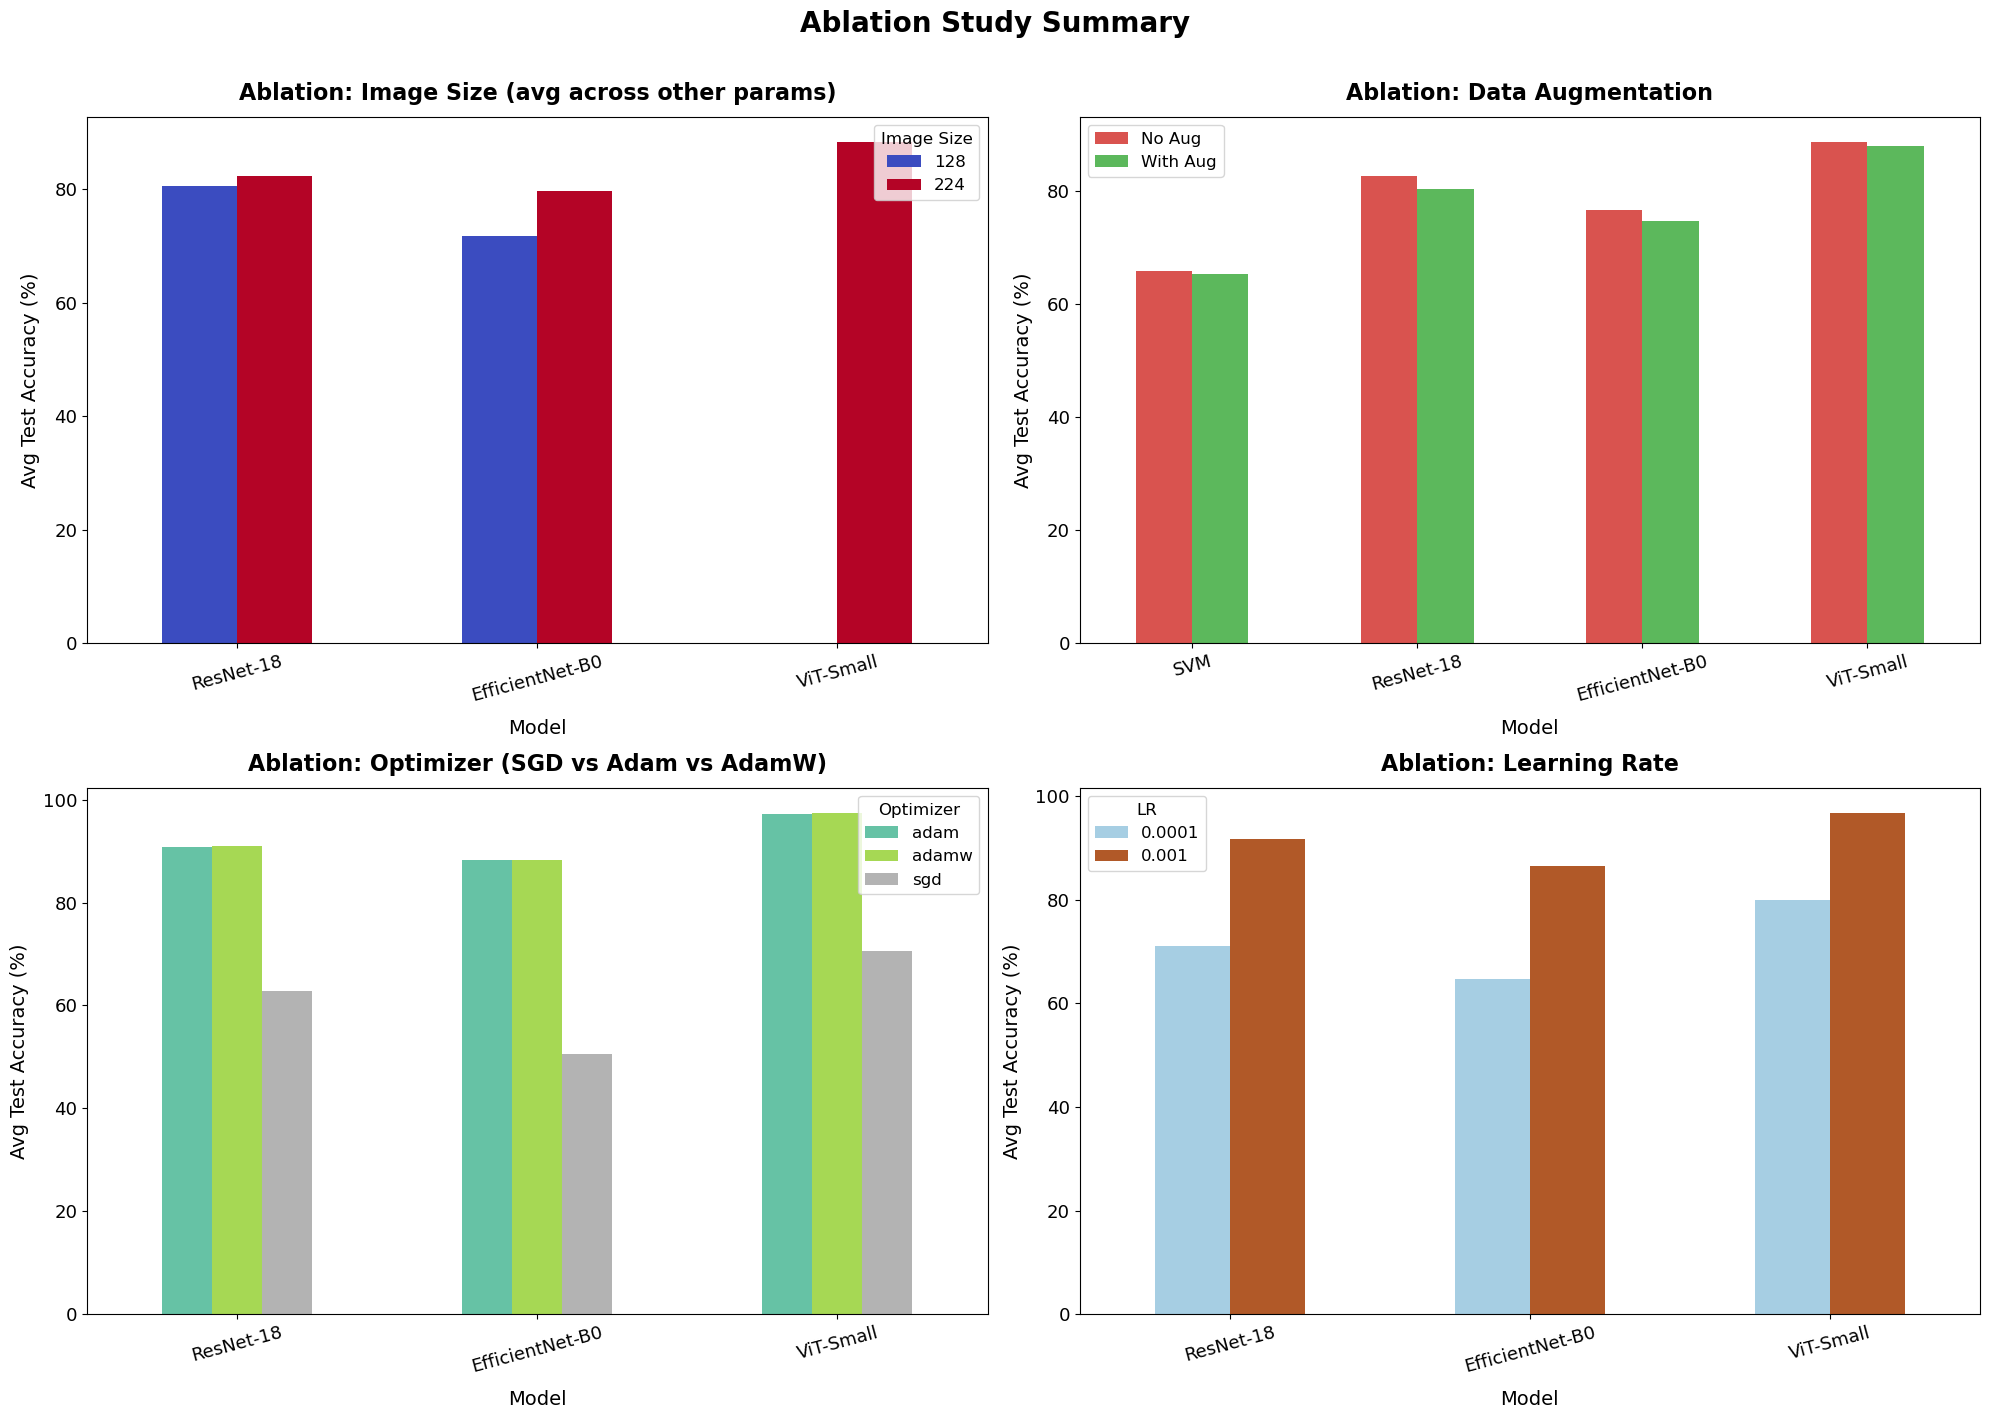

Saved: ablation_summary.png ✓


In [22]:
# Ablation Summary Plots

DL_ORDER    = ["resnet18", "efficientnet_b0", "vit_small"]
ALL_ORDER   = ["svm", "resnet18", "efficientnet_b0", "vit_small"]
MODEL_LABELS = {
    "svm": "SVM", "resnet18": "ResNet-18",
    "efficientnet_b0": "EfficientNet-B0", "vit_small": "ViT-Small"
}

TITLE_SIZE  = 16
LABEL_SIZE  = 14
TICK_SIZE   = 13
LEGEND_SIZE = 12

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Ablation 1: Image Size (DL only)
ax = axes[0, 0]
img_abl = (results_df[results_df["model"] != "svm"]
           .groupby(["model", "img_size"])["test_acc_%"].mean().unstack())
img_abl.index = pd.CategoricalIndex(img_abl.index, categories=DL_ORDER, ordered=True)
img_abl = img_abl.sort_index()
img_abl.index = [MODEL_LABELS[m] for m in img_abl.index]
img_abl.plot(kind="bar", ax=ax, colormap="coolwarm")
ax.set_title("Ablation: Image Size (avg across other params)", fontsize=TITLE_SIZE, fontweight="bold", pad=12)
ax.set_ylabel("Avg Test Accuracy (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xlabel("Model", fontsize=LABEL_SIZE, labelpad=10)
ax.tick_params(axis='x', rotation=15, labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=TICK_SIZE)
ax.legend(title="Image Size", fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

# Ablation 2: Augmentation (all models)
ax = axes[0, 1]
aug_abl = results_df.groupby(["model", "augment"])["test_acc_%"].mean().unstack()
aug_abl.index = pd.CategoricalIndex(aug_abl.index, categories=ALL_ORDER, ordered=True)
aug_abl = aug_abl.sort_index()
aug_abl.columns = ["No Aug", "With Aug"]
aug_abl.index = [MODEL_LABELS[m] for m in aug_abl.index]
aug_abl.plot(kind="bar", ax=ax, color=["#d9534f", "#5cb85c"])
ax.set_title("Ablation: Data Augmentation", fontsize=TITLE_SIZE, fontweight="bold", pad=12)
ax.set_ylabel("Avg Test Accuracy (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xlabel("Model", fontsize=LABEL_SIZE, labelpad=10)
ax.tick_params(axis='x', rotation=15, labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=TICK_SIZE)
ax.legend(fontsize=LEGEND_SIZE)

# Ablation 3: Optimizer (DL only)
ax = axes[1, 0]
dl_only = results_df[results_df["model"] != "svm"]
opt_abl = dl_only.groupby(["model", "optimizer"])["test_acc_%"].mean().unstack()
opt_abl.index = pd.CategoricalIndex(opt_abl.index, categories=DL_ORDER, ordered=True)
opt_abl = opt_abl.sort_index()
opt_abl.index = [MODEL_LABELS[m] for m in opt_abl.index]
opt_abl.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("Ablation: Optimizer (SGD vs Adam vs AdamW)", fontsize=TITLE_SIZE, fontweight="bold", pad=12)
ax.set_ylabel("Avg Test Accuracy (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xlabel("Model", fontsize=LABEL_SIZE, labelpad=10)
ax.tick_params(axis='x', rotation=15, labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=TICK_SIZE)
ax.legend(title="Optimizer", fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

# Ablation 4: Learning Rate (DL only)
ax = axes[1, 1]
lr_abl = dl_only.groupby(["model", "lr"])["test_acc_%"].mean().unstack()
lr_abl.index = pd.CategoricalIndex(lr_abl.index, categories=DL_ORDER, ordered=True)
lr_abl = lr_abl.sort_index()
lr_abl.index = [MODEL_LABELS[m] for m in lr_abl.index]
lr_abl.plot(kind="bar", ax=ax, colormap="Paired")
ax.set_title("Ablation: Learning Rate", fontsize=TITLE_SIZE, fontweight="bold", pad=12)
ax.set_ylabel("Avg Test Accuracy (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xlabel("Model", fontsize=LABEL_SIZE, labelpad=10)
ax.tick_params(axis='x', rotation=15, labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=TICK_SIZE)
ax.legend(title="LR", fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

plt.suptitle("Ablation Study Summary", fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation_summary.png ✓")

In [23]:
# Export Final Summary CSV
results_df.to_csv(RESULTS_DIR / "summary_table.csv", index=False)

print("Files saved to RESULTS_DIR:")
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")

print("\nFiles saved to FIG_DIR:")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name}")

print("\nFull experiment grid complete ✓")
print(f"Best overall model: {results_df.iloc[0]['run_key']}")
print(f"Best accuracy     : {results_df.iloc[0]['test_acc_%']}%")

Files saved to RESULTS_DIR:
  all_results.json
  summary_table.csv

Files saved to FIG_DIR:
  ablation_summary.png
  all_models_per_class_accuracy.png
  comparison_summary.png
  confusion_matrix_worst_classes.png
  efficientnet_b0_best_confusion_matrix.png
  efficientnet_b0_img128_ep10_lr0.0001_adam_augFalse_curves.png
  efficientnet_b0_img128_ep10_lr0.0001_adam_augTrue_curves.png
  efficientnet_b0_img128_ep10_lr0.0001_adamw_augFalse_curves.png
  efficientnet_b0_img128_ep10_lr0.0001_adamw_augTrue_curves.png
  efficientnet_b0_img128_ep10_lr0.0001_sgd_augFalse_curves.png
  efficientnet_b0_img128_ep10_lr0.0001_sgd_augTrue_curves.png
  efficientnet_b0_img128_ep10_lr0.001_adam_augFalse_curves.png
  efficientnet_b0_img128_ep10_lr0.001_adam_augTrue_curves.png
  efficientnet_b0_img128_ep10_lr0.001_adamw_augFalse_curves.png
  efficientnet_b0_img128_ep10_lr0.001_adamw_augTrue_curves.png
  efficientnet_b0_img128_ep10_lr0.001_sgd_augFalse_curves.png
  efficientnet_b0_img128_ep10_lr0.001_sgd_augTru